# MST Topology Trading Strategy

**Zara Nip** | Student ID: **12411910**

**Aryaa Gunavante** | Student ID:**12496718**

**Gabriella Wiem** | Student ID:**12506599**

**Hsiao-Chi Chen** | Student ID: **12498162**

**Shreya Enaganti**| Student ID:**12506493**

## Abstract

Financial markets exhibit complex dependency structures across assets, sectors, and asset classes. Traditional statistical arbitrage strategies often rely on pairwise relationships such as cointegration or correlation. However, these approaches fail to capture the global topology of asset relationships and may ignore higher-order structural information embedded in the market.

In this project, we model the market as a correlation network and extract its dominant structure using the Minimum Spanning Tree (MST)*(Mantegna, 1999). The MST provides a sparse representation of asset relationships by retaining only the most informative connections.

Our trading signal is based on deviations in effective resistance distance, a path-based metric that measures structural separation between assets in the network (Klein & Randić, 1993). When this distance deviates significantly from its historical level, we interpret it as a temporary dislocation and construct a dollar-neutral pair trade.

We evaluate the strategy across multiple portfolio configurations and perform parameter grid search and out-of-sample testing. The results suggest that network-based representations of asset correlations can provide useful signals for identifying transient dislocations in cross-asset relationships.

## Introduction

Financial markets are commonly studied as collections of individual assets whose prices follow their own stochastic processes. In practice, however, returns are driven by shared exposures such as interest-rate regimes, shifts in risk appetite, and macroeconomic shocks. These forces create complex and time-varying dependency structures within and across asset classes.

A standard correlation matrix is often used to capture pairwise comovement. While useful, this representation treats every pair of assets symmetrically and independently, offering little insight into which relationships are structurally important versus redundant.

We address this limitation using a graph-theoretic representation of the correlation matrix. Following Mantegna (1999), rolling pairwise correlations are transformed into a metric distance and used to construct a **minimum spanning tree (MST)**. The MST forms a unique connected weighted subgraph linking all assets while minimizing total distance. In doing so, it extracts a sparse backbone of the market’s dependency structure and removes redundant connections that would otherwise add noise.

The central question of this project is whether **temporary dislocations in the topology of this network** generate tradable signals. In particular, we study whether anomalous changes in the **effective resistance distance** between assets—defined as the cumulative weight along the unique path connecting two nodes—predict short-horizon mean reversion in relative returns.

Our hypothesis is economically intuitive: when assets that typically move together become structurally distant in the network, the deviation is more likely to revert than persist. This assumes that the underlying structural relationship observed over a rolling window has not fundamentally changed.

Our approach differs from traditional correlation-based pair trading in three key ways:

1. **Topological selection:**  
   We only trade pairs identified as neighbors in the MST. The tree enforces sparsity and ensures each relationship represents a structurally meaningful connection within the market network.

2. **Path-aware dislocation measurement:**  
   We measure deviations using **effective resistance** (Kirchhoff distance), which accounts for indirect relationships in the network. Two assets may exhibit moderate direct correlation but remain structurally close if connected through a short chain of strongly related assets.

3. **Regime-adaptive risk scaling:**  
   We incorporate the **Fiedler value**—the second-smallest eigenvalue of the MST Laplacian—as a measure of overall market connectivity. When the Fiedler value falls below its historical norm, the network becomes fragmented and mean-reversion signals are less reliable. In such regimes, the strategy reduces gross exposure to mitigate the risk of synchronized market moves.

In the remainder of this notebook, we construct the MST from rolling correlations, compute resistance-based dislocation signals, and implement a dollar-neutral statistical arbitrage strategy. We evaluate several portfolio configurations—including conservative, aggressive, and high-turnover variants—and examine robustness through parameter grid search and out-of-sample testing.

## Data

Our analysis uses a universe of 21 highly liquid exchange-traded funds (ETFs) spanning multiple asset classes, including equities, fixed income, commodities, and international markets. ETFs are well suited for statistical arbitrage due to their high liquidity and broad market exposure. Using assets across multiple sectors allows the correlation network to capture meaningful cross-asset relationships rather than purely sector-specific effects.

| Asset Class | ETFs | Count |
|---|---|---|
| Equity Sectors | XLF, XLK, XLE, XLV, XLI, XLY, XLP, XLB, XLU | 9 |
| Commodities | GLD, SLV, USO, DBA | 4 |
| Currencies | FXE, FXB, FXY, FXA | 4 |
| Fixed Income | TLT, IEF, HYG, LQD | 4 |

Daily adjusted closing prices are collected and converted to log returns. The return series are aligned in time, and missing observations are removed where necessary. Rolling correlation matrices computed from these returns form the basis for constructing the market network and generating trading signals.

All data is sourced from NASDAQ Data Link via the QuoteMedia/PRICES table. We use adjusted close prices to account for splits and dividends, ensuring returns are computed on an apples-to-apples basis across the full sample.

# Theory and Methodology

We construct the strategy by embedding financial returns into a metric space, extracting a sparse structural representation, and measuring deviations from that structure through spectral graph theory.

The mathematical pipeline proceeds in four steps:

1. We first convert correlations into a Euclidean metric representation of assets.
2. We then construct the minimum spanning tree to isolate the dominant dependency backbone.
3. From this tree, we derive the Laplacian and compute effective resistance to measure structural separation between each asset.
4. We subsequently analyze the Laplacian spectrum to obtain algebraic connectivity as an indicator of systemic integration.

Each step introduces a well-defined mathematical object with economic interpretation.

### 1. From Correlation to a Metric Space 

First, we begin with the Pearson correlation matrix of asset returns. Let $r_i(t)$ denote log returns. Define the Pearson correlation over a rolling window:

$$
\rho_{ij} = 
\frac{\mathbb{E}[r_i r_j] - \mathbb{E}[r_i]\mathbb{E}[r_j]}
{\sigma_i \sigma_j}.
$$

While correlation measures linear dependence, it does not define a proper geometric distance. To obtain a true metric space, we apply the nonlinear transformation. Per Mantegna (1999), we have the metric $d_{ij} = \sqrt{2(1 - \rho_{ij})}$, which represents the Euclidean separation between assets $i$ and $j$. With this metric, we observe that low correlation between assets $i$ and $j$ results in a larger geometric distance, $d_{ij}$, and vice versa. Assets that load on similar economic factors become geometrically close; assets driven by unrelated or opposing factors become far apart.

### 2, From the Metric Space to Minimum Spanning Tree 

Consider the complete weighted graph $G = (V, E, d_{ij})$ with $N$ nodes and $\binom{N}{2}$ edges. We construct the minimum spanning tree (MST), defined as $T = \arg\min_{T \subset G} \sum_{(i,j)\in T} d_{ij}$. This is the unique connected, acyclic subgraph that links all assets while minimizing the total metric length. By selecting only $N-1$ edges by use of Kruskal's algorithm, the MST extracts the sparsest structure that preserves global connectivity. This process filters out redundant correlations and isolates the dominant dependency backbone of the market. Economically, this backbone can be interpreted as the dominant channels through which common shocks and factor exposures propagate. Assets that are close in the tree share strong primary dependencies, and assets connected only through longer chains share weaker or more indirect exposure.

### 3. Graph Laplacian and Effective Resistance

Given the minimum spanning tree $T$, we encode its topology in matrix form through the graph Laplacian. Let $A$ denote the weighted adjacency matrix of the tree and let $D$ be the diagonal degree matrix with entries $D_{ii} = \sum_j A_{ij}$. The (weighted) Laplacian is defined as $L = D - A$, and it summarizes how variation propagates across nodes. 

From the Laplacian, we compute the effective resistance (Klein & Randić, 1993). Formally, the effective resistance between nodes $i$ and $j$ is
$$
\Omega_{ij} = (e_i - e_j)^T L^{\dagger} (e_i - e_j),
$$
where $L^{\dagger}$ is the Moore–Penrose pseudoinverse.

On a tree, there exists exactly one simple path between any two nodes. In this case, effective resistance reduces to the cumulative sum of edge weights along that path: $\Omega_{ij} = \sum_{(k,\ell)\in \text{path}(i,j)} d_{k\ell}$. Therefore, on the MST, the effective resistance can be interpreted as providing a path-aware structural distance. Unlike raw correlation, which measures only local pairwise dependence, effective resistance aggregates the entire sequence of dependencies linking two assets through intermediary nodes. The metric essentially quantifies structural separation within the market backbone, where assets with short chains are characterized by low resistance, while assets separated by long chains have high resistance.

### 4. Spectral Decomposition and Algebraic Connectivity

Applying eigen-decomposition to the Laplacian gives us the second eigenvalue, termed the Fiedler value, denoted by $\lambda_2$. The Fiedler value measures the algebraic connectivity of the graph. Larger $\lambda_2$ values imply stronger connectivity and $\lambda_2 = 0$ if and only if the graph is disconnected. 

In the context of financial markets, $\lambda_2$ serves as a quantitative measure of systemic integration. When $\lambda_2$ increases, the network becomes more cohesive, indicating that assets are moving in a more synchronized manner. Empirical evidence in Onnela et al. (2003) shows that during market crises the minimum spanning tree becomes more compact and star-like, reflecting heightened cross-asset correlation and tighter structural coupling.

Similarly, Pozzi, Di Matteo, and Aste (2013) demonstrate that changes in network topology are closely linked to shifts in realized correlation and diversification potential. In highly integrated regimes, structural dispersion falls and relative-value relationships weaken.

Accordingly, we interpret elevated $\lambda_2$ values as indicative of tightly synchronized market states, often associated with systemic stress. In such regimes, mean-reversion across pairs becomes less reliable, motivating dynamic adjustment of gross exposure based on deviations of $\lambda_2$ from its historical norm.

### 5. Structural Signal Construction

Having established the mathematical framework for extracting topological structure, we now formalize the process of converting effective resistance measurements into implementable trading signals. The procedure consists of four stages: (1) normalization of resistance dynamics, (2) signal generation, (3) volatility-targeted pair sizing, and (4) systemic risk scaling via algebraic connectivity.

#### 5.1. Rolling Z-Score Normalization
For each asset pair $(i,j)$ connected by an MST edge, we observe the time series of effective resistance $\Omega_{ij}(t)$ at weekly frequency $t = 1, 2, \ldots, T$. To identify structural deviations, we compute rolling statistics over a lookback window of $L = 60$ weeks:
$$
\mu_{ij}(t) = \frac{1}{L} \sum_{\tau=t-L+1}^{t} \Omega_{ij}(\tau), \quad \sigma_{ij}(t) = \sqrt{\frac{1}{L-1} \sum_{\tau=t-L+1}^{t} \left( \Omega_{ij}(\tau) - \mu_{ij}(t) \right)^2}.
$$
The standardized resistance deviation, or z-score, is then defined as:
$$
z_{ij}(t) = \frac{\Omega_{ij}(t) - \mu_{ij}(t)}{\max(\sigma_{ij}(t), \epsilon)},
$$
where $\epsilon = 10^{-6}$ prevents division by zero. To prevent extreme outliers from dominating the signal, we apply symmetric clipping: $z_{ij}(t) \in [-3, 3]$. 

A positive z-score indicates that the current effective resistance exceeds its recent historical norm, meaning the pair has drifted further apart in the structural sense than usual. Conversely, a negative z-score indicates tighter-than-normal coupling.

#### 5.2. Signal with Exponential Dampening

The absolute magnitude of the resistance z-score is used to measure the severity of topological dislocation. A large $|z_{ij}|$ indicates that pairwise resistance has deviated substantially from its historical benchmark, and this deviation is used to guide both trade entry and position sizing.

To construct a bounded, continuous signal that trades in the direction of this drift, we introduce exponential dampening. Let $\bar{R}(t)$ denote the cross-sectional mean of all pairwise effective resistances at time $t$:
$$
\bar{R}(t) = \frac{2}{N(N-1)} \sum_{i < j} \Omega_{ij}(t).
$$
The signal for pair $(i,j)$ is then:
$$
s_{ij}(t) = z_{ij}(t) \cdot \exp\left( -\frac{\Omega_{ij}(t)}{\bar{R}(t)} \right).
$$
The exponential term $\exp(-\Omega_{ij} / \bar{R})$ serves as a distance-based discount factor. Pairs that are structurally far apart even under normal conditions ($\Omega_{ij} \gg \bar{R}$) receive reduced signal weight, as their large baseline separation makes incremental drift less informative. Conversely, pairs with $\Omega_{ij} \approx \bar{R}$ receive full signal weight. 

#### 5.3. Volatility-Targeted Pair Weights

To translate signals into implementable positions, we use a volatility-targeting framework that scales each pair according to its recent realized risk. For each selected pair of assets $(i,j)$, we construct the dollar-neutral spread return as the difference between their daily log returns:
$$
S_{ij}(\tau) = r_i(\tau) - r_j(\tau),
$$
where $r_i(\tau)$ and $r_j(\tau)$ denote daily log returns.

We then compute the annualized spread volatility over a rolling 60-day window:
$$
\sigma_{\text{spread}, ij}(t) = \sqrt{252} \cdot \mathrm{Std}\big(S_{ij}(\tau)\big),
$$
where the standard deviation is calculated using the same 60-day estimation window. To avoid excessive position sizes when the two assets move very closely together, we impose a minimum volatility floor such that
$$
\sigma_{\text{spread}, ij}(t) \geq 0.01.
$$

The notional weight assigned to pair $(i,j)$ is then defined as
$$
w_{ij}(t) = \frac{\sigma_{\text{target}} \cdot s_{ij}(t)}{\sigma_{\text{spread}, ij}(t)} \cdot \gamma(t),
$$
where $\sigma_{\text{target}} = 0.10$ is the target annualized portfolio volatility and $\gamma(t)$ is the Fiedler-based risk scaling factor described below. This construction ensures that lower-volatility pairs receive larger notional allocations, while higher-volatility pairs are scaled down.

Within each pair, positions are implemented in a dollar-neutral long-short form, so that the long and short legs have equal notional magnitude. Individual pair weights are clipped to
$$
w_{ij}(t) \in [-1.5, 1.5]
$$
to prevent excessive concentration.

#### 5.4. Long-Short Assignment via Lead-Lag Analysis

To assign the long and short legs within each selected pair, we compare recent cumulative performance over a 20-day window:
$$
C_i(t) = \prod_{\tau=t-19}^{t} (1 + r_i(\tau)) - 1, \quad C_j(t) = \prod_{\tau=t-19}^{t} (1 + r_j(\tau)) - 1.
$$
If $C_i(t) \leq C_j(t)$, asset $i$ is designated as the lagging asset and asset $j$ as the leading asset; otherwise, the assignment is reversed. The lagging asset is placed on the long side and the leading asset on the short side, so that each trade forms a structured relative-value position within the pair.

The pair weight is then mapped into symmetric dollar-neutral asset-level exposures. Hence, if asset $i$ is the lagging asset and asset $j$ is the leading asset, the implemented position is
$$
w_i(t)=+w_{ij}(t), \qquad w_j(t)=-w_{ij}(t).
$$
This one-for-one construction keeps the long and short legs equal in notional size and ensures that each trade is implemented as a dollar-neutral pair position.

#### 5.5. Systemic Risk Throttle via Fiedler Value

The Fiedler value $\lambda_2(t)$ serves as a dynamic measure of market integration. To distinguish normal market conditions from unusually synchronized regimes, we compute the expanding mean $\bar{\lambda}_2(t)$ and standard deviation $\hat{\sigma}_{\lambda}(t)$ of the Fiedler series up to time $t$, with a minimum lookback of 20 weeks. We then define an upper synchronization threshold:
$$
\lambda_{\text{cap}}(t) = \bar{\lambda}_2(t) + 2.75 \hat{\sigma}_{\lambda}(t).
$$
When $\lambda_2(t) > \lambda_{\text{cap}}(t)$, the market is interpreted as being in an unusually high-connectivity regime, where the MST has become exceptionally compact and cross-asset comovement is elevated. In such states, relative-value relationships are more vulnerable to systemic market moves, motivating a reduction in gross exposure. Accordingly, we define the risk scaling factor:
$$
\gamma(t) = 
\begin{cases}
0.5, & \text{if } \lambda_2(t) > \lambda_{\text{cap}}(t), \\
1.0, & \text{otherwise}.
\end{cases}
$$
All pair weights are multiplied by $\gamma(t)$, effectively halving exposure during periods of unusually strong market-wide synchronization. In this paper, we will investigate whether protecting against a low Fiedler value--one that indicates market fragmentation--is beneficial. 

#### 2.5.6 Portfolio-Level Aggregation and Gross Leverage Cap
At each rebalancing date $t$, we restrict the candidate set to pairs that form edges in the current MST $T(t)$, ensuring topological consistency. From this set, we rank all pairs by absolute signal strength $|s_{ij}(t)|$ and retain the top $K = 8$ pairs. For each selected pair, the corresponding asset-level weights are:
$$
w_i(t) = \sum_{j: (i,j) \in \mathcal{P}(t)} w_{ij}(t), \quad w_j(t) = -\sum_{i: (i,j) \in \mathcal{P}(t)} w_{ij}(t),
$$
where $\mathcal{P}(t)$ denotes the set of active pairs at time $t$. To enforce prudent leverage, we compute the gross notional exposure:
$$
G(t) = \sum_{i} |w_i(t)|.
$$
If $G(t) > G_{\max} = 4.0$, we rescale all weights proportionally: $w_i(t) \leftarrow w_i(t) \cdot (G_{\max} / G(t))$.
This completes the signal construction pipeline. The strategy rebalances weekly, holding positions from Friday to Friday, with transaction costs deducted proportionally to turnover at each rebalance.

To recap, we calculate Mantegna distances → MST construction → effective resistance computation → z-score normalization → volatility-targeted pair sizing → Fiedler-based risk throttle.

# Helper Functions + Data Loading

In [1]:
from pathlib import Path
import warnings

import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from mst_strategy import *

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

ETF_UNIVERSE = [
    'XLF','XLK','XLE','XLV','XLI','XLY','XLP','XLB','XLU',
    'GLD','SLV','USO','DBA',
    'FXE','FXB','FXY','FXA',
    'TLT','IEF','HYG','LQD'
]

START_DATE = '2018-01-01'
END_DATE = '2025-12-31'
DATA_DIR = Path('data')
RNG_SEED = 42
np.random.seed(RNG_SEED)

## Data Loading and Preparation

In [2]:
prices = load_or_fetch_prices(ETF_UNIVERSE, START_DATE, END_DATE, str(DATA_DIR))
returns = prices.pct_change().dropna()

print(f'Date range: {prices.index.min().date()} to {prices.index.max().date()}')
print(f'Assets: {prices.shape[1]}')
print(f'Observations: {prices.shape[0]}')
print(f'Missing values in price matrix: {int(prices.isna().sum().sum())}')

prices.head()

Date range: 2018-01-02 to 2025-05-29
Assets: 21
Observations: 1862
Missing values in price matrix: 0


ticker,DBA,FXA,FXB,FXE,FXY,GLD,HYG,IEF,LQD,SLV,...,USO,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,17.6710,75.1934,124.8302,112.0236,85.4700,125.1500,62.9520,91.7215,98.1064,16.2100,...,96.5600,54.0963,55.0574,24.7029,67.9851,60.4606,47.7479,42.7125,75.2431,94.2526
2018-01-03,17.6617,75.2703,124.0650,111.5512,85.3000,124.8200,63.2547,91.8173,98.2851,16.1700,...,98.7200,54.4752,55.8819,24.8357,68.3513,60.9649,47.7310,42.3770,75.9631,94.6854
2018-01-04,17.6337,75.5487,124.4145,112.1104,85.1300,125.4600,63.3628,91.7738,98.2526,16.2300,...,98.9600,54.9510,56.2193,25.0657,68.8514,61.2731,47.8661,42.0251,76.0711,94.9958
2018-01-05,17.5406,75.5967,124.5468,111.8019,84.8400,125.3300,63.4061,91.6604,98.2201,16.2200,...,98.4800,55.3916,56.1968,25.1365,69.3248,61.9174,48.0773,42.0087,76.7190,95.7484
2018-01-08,17.4195,75.3087,124.5373,111.1271,84.8533,125.3100,63.3556,91.6169,98.2120,16.1500,...,99.0400,55.4709,56.5341,25.1011,69.6106,62.1509,48.1955,42.4015,76.4400,95.8613


In [3]:
analysis_data = (
    f"Our sample spans {prices.shape[0]} daily observations across {prices.shape[1]} ETFs. "
    f"After differencing, we retain {returns.shape[0]} return rows and the average daily absolute move is "
    f"{returns.abs().mean().mean():.4f}."
)
print(analysis_data)

Our sample spans 1862 daily observations across 21 ETFs. After differencing, we retain 1861 return rows and the average daily absolute move is 0.0079.


# Exploratory Data Analysis

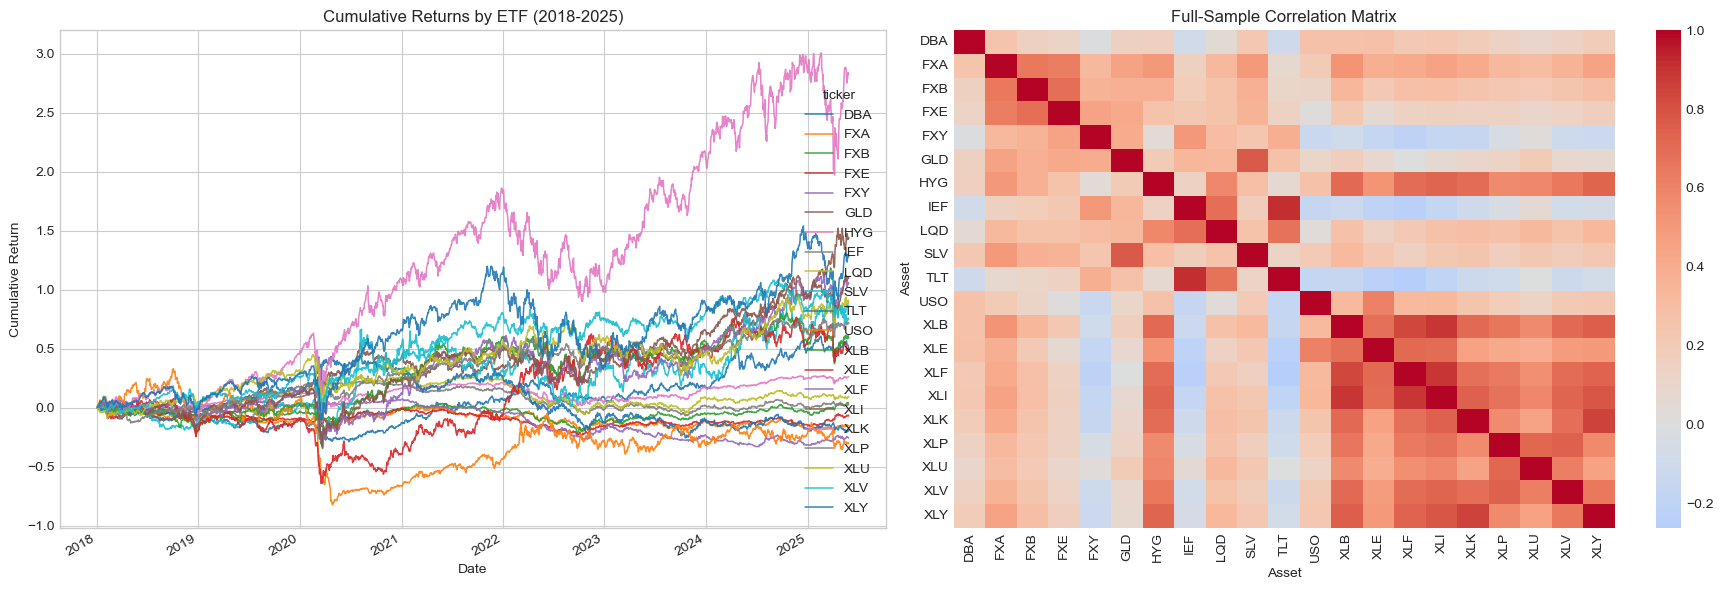

In [4]:
cum_returns = (1 + returns).cumprod() - 1
corr_full = returns.corr()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
cum_returns.plot(ax=ax[0], linewidth=1.1, alpha=0.9)
ax[0].set_title('Cumulative Returns by ETF (2018-2025)')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Cumulative Return')

sns.heatmap(corr_full, cmap='coolwarm', center=0, ax=ax[1])
ax[1].set_title('Full-Sample Correlation Matrix')
ax[1].set_xlabel('Asset')
ax[1].set_ylabel('Asset')

plt.tight_layout()
plt.show()

The cumulative return dispersion confirms that the asset universe represents a heterogeneous opportunity set rather than a single-factor basket. While equity sector ETFs display persistent co-movement, commodities, currencies, and duration-sensitive bonds follow distinct return trajectories. This cross-asset heterogeneity is important for the MST approach, as it creates meaningful branching structure in the correlation network.

The correlation heatmap further motivates the use of topology reduction. Many pairwise correlations are non-zero, producing a dense and highly connected network. However, only a subset of these relationships are structurally important for shortest-path connectivity. The Minimum Spanning Tree extracts this backbone by retaining only the most informative links while removing redundant connections.

In [5]:
upper_corr = corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool)).stack()
print(
    f"Our average pairwise correlation is {upper_corr.mean():.4f}, "
    f"with a minimum of {upper_corr.min():.4f} and a maximum of {upper_corr.max():.4f}."
)

Our average pairwise correlation is 0.2896, with a minimum of -0.2623 and a maximum of 0.9115.


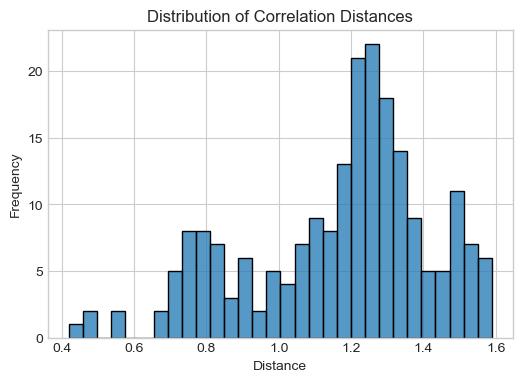

In [6]:
distances = np.sqrt(2 * (1 - corr_full))

upper_dist = distances.where(np.triu(np.ones(distances.shape), k=1).astype(bool)).stack()

plt.figure(figsize=(6,4))
sns.histplot(upper_dist, bins=30)
plt.title("Distribution of Correlation Distances")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

The distance distribution highlights the range of structural relationships in the asset universe. Assets with strong positive correlations map to shorter distances, while weakly related assets appear further apart in the network metric space used to construct the MST.

# MST Construction and Visualization

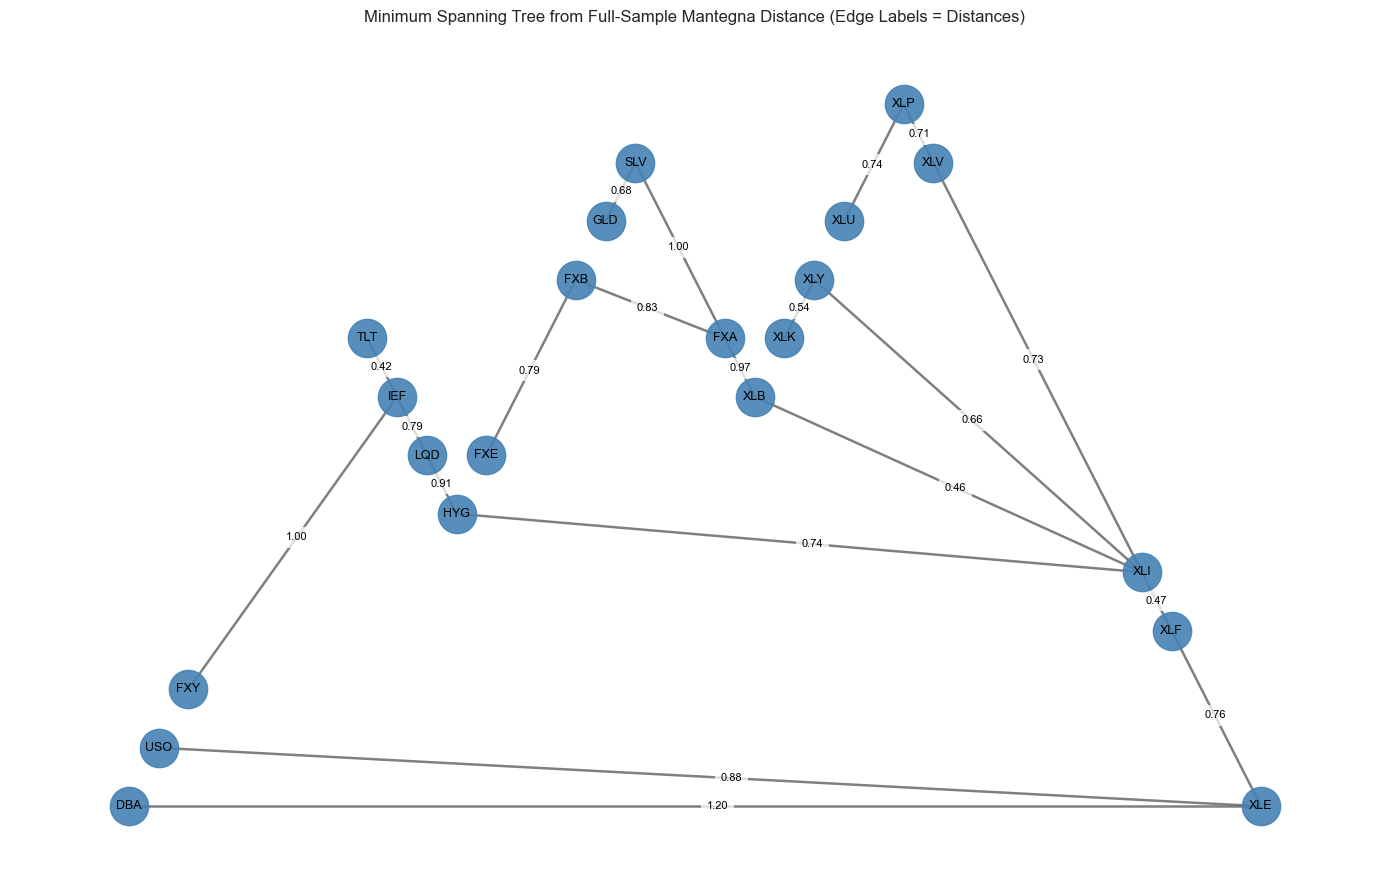

In [7]:
distance_full = mantegna_distance(corr_full)
assets = list(distance_full.columns)
mst_edges_full = build_mst_kruskal(distance_full, assets)

G = nx.Graph()
for idx, name in enumerate(assets):
    G.add_node(name, idx=idx)
for i, j, w in mst_edges_full:
    G.add_edge(assets[i], assets[j], weight=w)

plt.figure(figsize=(14, 9))

# Prefer Graphviz tree layout (minimal edge overlap); fall back to planar embedding.
try:
    from networkx.drawing.nx_pydot import graphviz_layout
    pos = graphviz_layout(G, prog='dot')
except Exception:
    pos = nx.planar_layout(G, scale=2)

nx.draw_networkx_nodes(G, pos, node_size=760, node_color='steelblue', alpha=0.9)
nx.draw_networkx_edges(
    G,
    pos,
    width=1.8,
    alpha=0.85,
    edge_color='dimgray',
    connectionstyle='arc3,rad=0.04',
)
nx.draw_networkx_labels(G, pos, font_size=9, font_color='black')

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8,
    label_pos=0.52,
    rotate=False,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.75),
)

plt.title('Minimum Spanning Tree from Full-Sample Mantegna Distance (Edge Labels = Distances)')
plt.axis('off')
plt.tight_layout()
plt.show()


The full-sample MST highlights the dominant structural relationships across our ETF universe. Because the tree retains only \(N-1\) edges, it provides a sparse representation of the correlation network while preserving global connectivity.

Nodes with higher degree act as structural hubs within the network. In our sample, XLI emerges as the highest-degree node, suggesting that the industrial sector plays an important bridging role across multiple equity sectors. Such hubs are important because shocks propagating through them can influence multiple parts of the network simultaneously.

The sparsity of the MST is central to the trading design. By restricting attention to the tree, we focus only on the strongest structural relationships while avoiding the noise inherent in a fully connected correlation graph.

In [8]:
degrees = pd.Series(dict(G.degree())).sort_values(ascending=False)
avg_edge_distance = np.mean([w for _, _, w in mst_edges_full])
print(f"The tree contains {len(mst_edges_full)} edges across {len(assets)} assets.")
print(f"The highest-degree node is {degrees.index[0]} with degree {int(degrees.iloc[0])}.")
print(f"The average MST edge distance is {avg_edge_distance:.4f}.")

The tree contains 20 edges across 21 assets.
The highest-degree node is XLI with degree 5.
The average MST edge distance is 0.7648.


## Rolling MST and Effective Resistance

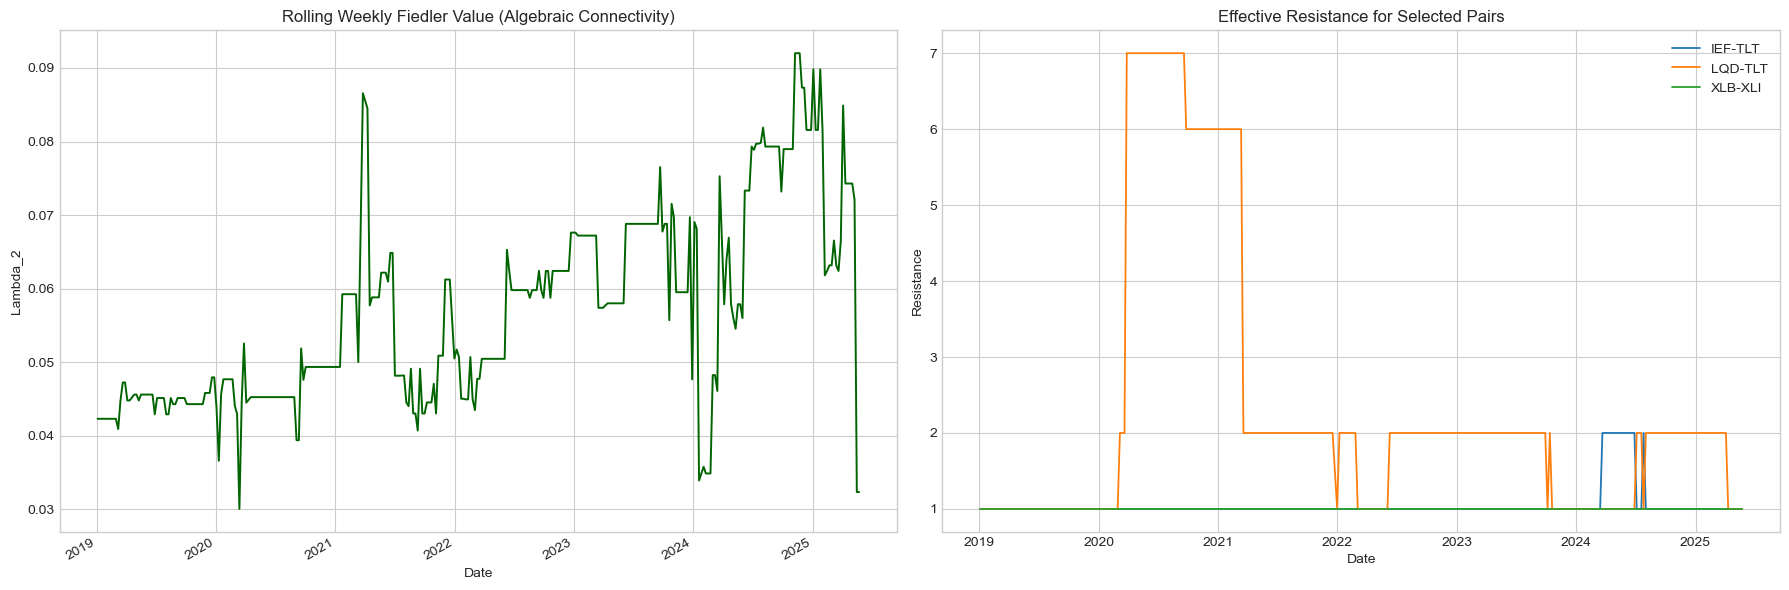

In [9]:
pipeline = run_weekly_mst_pipeline(prices, corr_window=252, resistance_lookback=60)
fiedler_values = pipeline['fiedler_values']
effective_resistances = pipeline['effective_resistances']
mst_by_date = pipeline['mst_by_date']

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
fiedler_values.plot(ax=ax[0], color='darkgreen', linewidth=1.4)
ax[0].set_title('Rolling Weekly Fiedler Value (Algebraic Connectivity)')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Lambda_2')

first_date = sorted(mst_by_date.keys())[0]
last_date = sorted(mst_by_date.keys())[-1]
edge_set_first = {(min(i,j), max(i,j)) for i, j, _ in mst_by_date[first_date]}
edge_set_last = {(min(i,j), max(i,j)) for i, j, _ in mst_by_date[last_date]}
common_edges = len(edge_set_first & edge_set_last)

sample_pairs = []
for i, j, _ in mst_by_date[last_date][:3]:
    sample_pairs.append((prices.columns[i], prices.columns[j]))

for a, b in sample_pairs:
    series = pd.Series({d: effective_resistances[d].loc[a, b] for d in sorted(effective_resistances)})
    ax[1].plot(series.index, series.values, label=f'{a}-{b}', linewidth=1.3)

ax[1].set_title('Effective Resistance for Selected Pairs')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Resistance')
ax[1].legend(loc='best')

plt.tight_layout()
plt.show()

We find that algebraic connectivity is clearly time-varying, which supports treating \( \lambda_2 \) as a dynamic market state variable rather than a fixed calibration constant. In our implementation, unusually high values of \( \lambda_2 \) indicate stronger global coupling across the asset network, meaning shocks are more likely to propagate broadly and diversification benefits decline. For this reason, \( \lambda_2 \) is used as a risk-control variable, with portfolio exposure scaled down when connectivity becomes unusually elevated.

The effective-resistance series for representative pairs exhibit persistent variation and occasional large deviations from their recent historical range. We interpret these deviations as topological dislocations in the network structure. The absolute magnitude of the resistance z-score measures the severity of the dislocation: when resistance moves far from its historical benchmark, the strategy treats this as a trade entry signal and scales position sizes accordingly.

In [10]:
print(f"we compute {len(fiedler_values)} weekly MST observations.")
print(f"Lambda_2 mean is {fiedler_values.mean():.4f} with standard deviation {fiedler_values.std():.4f}.")
print(f"The overlap between the first and last weekly tree is {common_edges} common edges.")

we compute 323 weekly MST observations.
Lambda_2 mean is 0.0566 with standard deviation 0.0131.
The overlap between the first and last weekly tree is 12 common edges.


# Implementation and Signal Generation

This section translates the network framework into a systematic trading strategy. Using the rolling MST constructed in the previous section, we compute effective-resistance z-scores for each edge in the tree. These z-scores measure how far the current structural relationship between two assets deviates from its recent historical level.

At each rebalance date, candidate pairs are restricted to MST edges to ensure that signals remain tied to the dominant topology of the market network. The strategy ranks these pairs by the absolute magnitude of their resistance signals and selects the strongest opportunities for trading. Positions are constructed as dollar-neutral spreads and scaled according to volatility targeting and risk constraints.

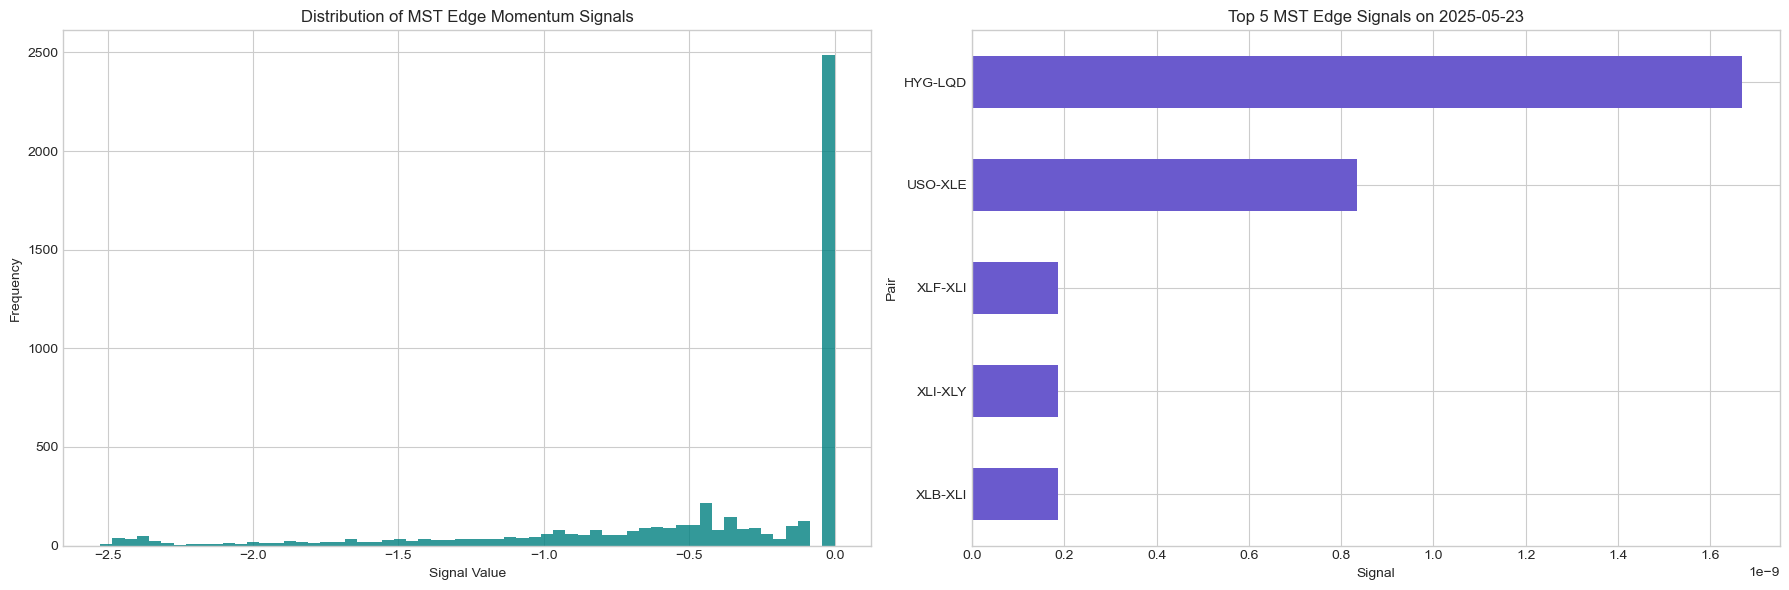

In [11]:
signals = pipeline['signals']
asset_names = [str(c) for c in prices.columns]

# Collect only MST-edge signal values for statistics and plotting
signal_values = []
for d in sorted(signals):
    s = signals[d]
    if d in mst_by_date:
        for i_idx, j_idx, _ in mst_by_date[d]:
            a, b = asset_names[i_idx], asset_names[j_idx]
            a_s, b_s = min(a, b), max(a, b)
            val = float(s.loc[a_s, b_s])
            if np.isfinite(val):
                signal_values.append(val)

signal_values = np.array(signal_values, dtype=float)

# True reproduces current results; set False to allow all asset pairs
use_mst_edges_only = True

# Choose lambda regime control: "none", "small_only", "large_only", "two_sided"
lambda_risk_mode = "large_only"

strategy_params = {
    "corr_window": 252,
    "resistance_lookback": 60,
    "sigma_target": 0.10,
    "max_pairs": 8,
    "beta_window": 60,
    "leader_window": 20,
    "max_pair_weight": 1.5,
    "max_gross_leverage": 4.0,
    "lambda_risk_mode": lambda_risk_mode,
    "lambda_min_periods": 20,
    "lambda_z_threshold": 2.75,
    "lambda_shrink_small": 0.5,
    "lambda_shrink_large": 0.5,
    "use_mst_edges_only": use_mst_edges_only,
}

weights = run_strategy_with_params(prices, strategy_params)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].hist(signal_values, bins=60, color='teal', alpha=0.8)
ax[0].set_title('Distribution of MST Edge Momentum Signals')
ax[0].set_xlabel('Signal Value')
ax[0].set_ylabel('Frequency')

signal_dates = sorted(signals.keys())
sample_date = signal_dates[-1]
# Show MST-edge signals for the last date
if sample_date in mst_by_date:
    edge_signals = {}
    for i_idx, j_idx, _ in mst_by_date[sample_date]:
        a, b = asset_names[i_idx], asset_names[j_idx]
        a_s, b_s = min(a, b), max(a, b)
        val = float(signals[sample_date].loc[a_s, b_s])
        if np.isfinite(val):
            edge_signals[f'{a_s}-{b_s}'] = val
    sample_signal = pd.Series(edge_signals).sort_values()
    sample_signal.tail(5).plot(kind='barh', ax=ax[1], color='slateblue')
    ax[1].set_title(f'Top 5 MST Edge Signals on {sample_date.date()}')
    ax[1].set_xlabel('Signal')
    ax[1].set_ylabel('Pair')

plt.tight_layout()
plt.show()


Signal Interpretation:

The signal distribution is centered near zero, with tail observations representing rare structural dislocations in the network. These deviations drive trading activity. An exponential damping term reduces signals for pairs that are already distant in the MST, concentrating exposure on strongly connected assets experiencing unusually large deviations.

MST Pair Selection:

Candidate trades are restricted to MST edges to keep signals tied to the network’s dominant structure. Each week, edges are ranked by absolute signal magnitude and the strongest opportunities are selected. In the baseline configuration, the strategy trades the top eight pairs, maintaining diversification while avoiding weak signals.

In [12]:
pair_counts = pd.Series({d: len(v) for d, v in weights['pair_weights'].items()}).sort_index()
print(f"We generate {len(signal_values)} finite pair signals across the sample.")
print(f"Signal mean is {signal_values.mean():.4f} and signal standard deviation is {signal_values.std():.4f}.")
print(f"Average simultaneous pairs held is {pair_counts.mean():.2f}, with minimum {pair_counts.min():.0f}.")

We generate 5260 finite pair signals across the sample.
Signal mean is -0.4546 and signal standard deviation is 0.6260.
Average simultaneous pairs held is 8.00, with minimum 8.


### Strategy Simulation — Zero Transaction Costs

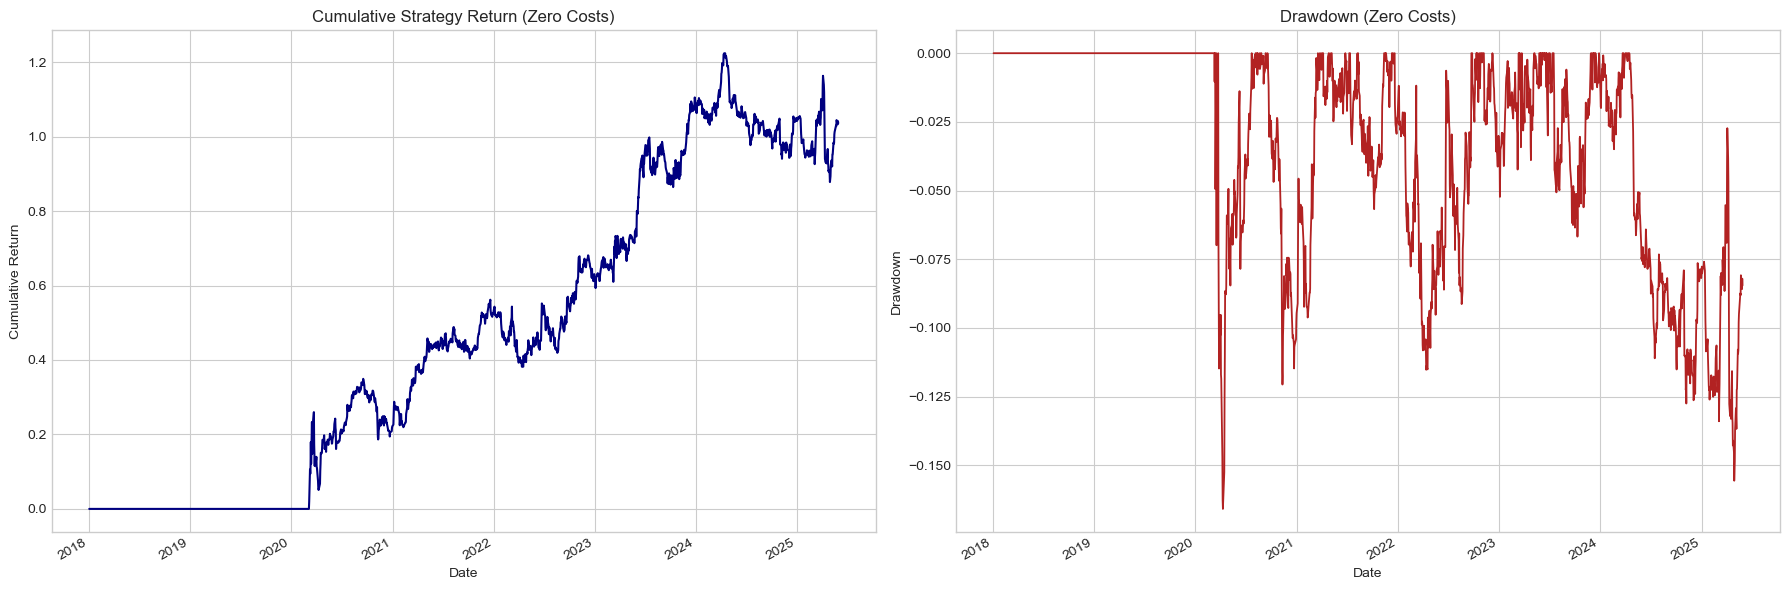

,Zero Cost Value
Cumulative Return,1.0360
Annualized Return,0.1010
Annualized Volatility,0.1350
Sharpe Ratio,0.6319
Sortino Ratio,0.7531
Maximum Drawdown,-0.1659
VaR 95%,-0.0110
CVaR 95%,-0.0182
Win Rate,0.3722
Number of Trades,667.0000


In [13]:
sim_zero = simulate_strategy(prices, signals, weights, transaction_cost_bps=0)
metrics_zero = compute_performance_metrics(
    sim_zero.daily_returns,
    rf_rate=0.02,
    trade_count=sim_zero.trade_count,
    average_holding_period=sim_zero.average_holding_period,
)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sim_zero.cumulative_returns.plot(ax=ax[0], color='navy', linewidth=1.5)
ax[0].set_title('Cumulative Strategy Return (Zero Costs)')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Cumulative Return')

sim_zero.drawdown.plot(ax=ax[1], color='firebrick', linewidth=1.3)
ax[1].set_title('Drawdown (Zero Costs)')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Drawdown')

plt.tight_layout()
plt.show()

metrics_zero.to_frame('Zero Cost Value')

In the frictionless setting we isolate the informational content of the topology signal and the effectiveness of volatility targeting. The strategy produces a 10.1% annualized return with a Sharpe ratio of 0.63, indicating that structural deviations in the MST contain measurable predictive information.

The maximum drawdown of roughly 16.6% suggests that the signal experiences periodic regime stress but does not rely on rare extreme gains. The relatively smooth equity curve indicates that the alpha source is distributed across many trades rather than concentrated in a few large events.

In [14]:
print(
    f"Our zero-cost cumulative return is {metrics_zero['Cumulative Return']:.4f}, "
    f"with annualized return {metrics_zero['Annualized Return']:.4f} and Sharpe {metrics_zero['Sharpe Ratio']:.4f}."
)
print(
    f"The maximum drawdown is {metrics_zero['Maximum Drawdown']:.4f}, "
    f"with {metrics_zero['Number of Trades']:.0f} trades and average holding period {metrics_zero['Average Holding Period']:.2f} days."
)

Our zero-cost cumulative return is 1.0360, with annualized return 0.1010 and Sharpe 0.6319.
The maximum drawdown is -0.1659, with 667 trades and average holding period 15.77 days.


### Strategy Simulation — With Transaction Costs

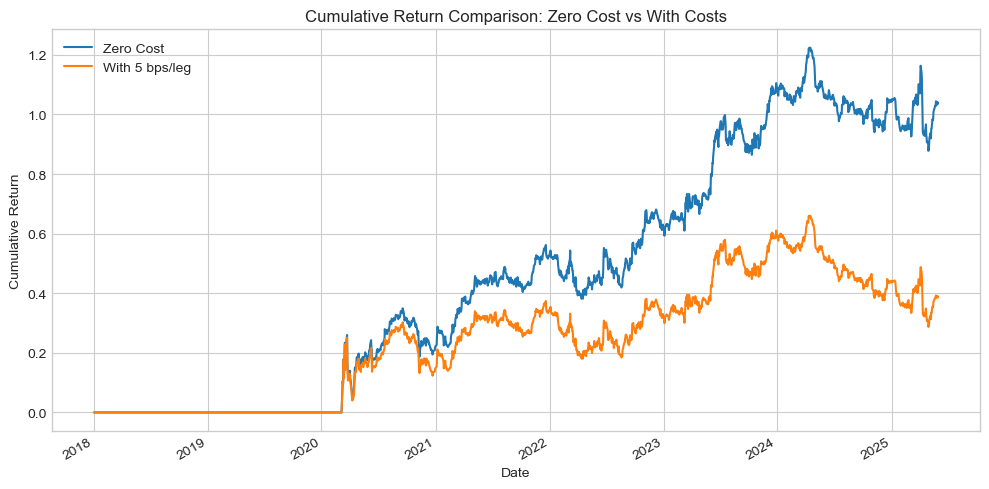

,Zero Cost,With Costs,Delta (With - Zero)
Cumulative Return,1.0360,0.3870,-0.6490
Annualized Return,0.1010,0.0453,-0.0557
Annualized Volatility,0.1350,0.1338,-0.0012
Sharpe Ratio,0.6319,0.2481,-0.3838
Sortino Ratio,0.7531,0.2955,-0.4576
Maximum Drawdown,-0.1659,-0.2246,-0.0588
VaR 95%,-0.0110,-0.0111,-0.0001
CVaR 95%,-0.0182,-0.0183,-0.0001
Win Rate,0.3722,0.3582,-0.0140
Number of Trades,667.0000,667.0000,0.0000


In [15]:
# 5 bps per leg is a standard institutional estimate for highly liquid ETFs.
# Round-trip pair cost is approximately 10 bps when both legs are opened and later closed.
cost_bps_per_leg = 5
sim_cost = simulate_strategy(prices, signals, weights, transaction_cost_bps=cost_bps_per_leg)
metrics_cost = compute_performance_metrics(
    sim_cost.daily_returns,
    rf_rate=0.02,
    trade_count=sim_cost.trade_count,
    average_holding_period=sim_cost.average_holding_period,
)

comparison = pd.concat([
    metrics_zero.rename('Zero Cost'),
    metrics_cost.rename('With Costs')
], axis=1)
comparison['Delta (With - Zero)'] = comparison['With Costs'] - comparison['Zero Cost']

fig, ax = plt.subplots(figsize=(10, 5))
sim_zero.cumulative_returns.plot(ax=ax, label='Zero Cost', linewidth=1.5)
sim_cost.cumulative_returns.plot(ax=ax, label='With 5 bps/leg', linewidth=1.5)
ax.set_title('Cumulative Return Comparison: Zero Cost vs With Costs')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.tight_layout()
plt.show()

comparison

Introducing realistic trading costs materially reduces performance, primarily because the strategy operates at moderate turnover. With a cost assumption of 5 bps per leg, typicl for ETFs that are generally deep and liquid, the Sharpe ratio declines from 0.63 to 0.25, while annualized return falls to approximately 4.5%.

Volatility remains nearly unchanged, indicating that transaction costs primarily reduce expected returns rather than altering the risk profile of the strategy. This suggests that the signal retains predictive power, but profitability becomes sensitive to execution efficiency and turnover management.

In [16]:
print(
    f"With costs, cumulative return is {metrics_cost['Cumulative Return']:.4f} and Sharpe is {metrics_cost['Sharpe Ratio']:.4f}. "
    f"The Sharpe drag relative to zero-cost is {metrics_cost['Sharpe Ratio'] - metrics_zero['Sharpe Ratio']:.4f}."
)
print(
    f"The annualized return declines by {metrics_cost['Annualized Return'] - metrics_zero['Annualized Return']:.4f}, "
    f"while max drawdown changes by {metrics_cost['Maximum Drawdown'] - metrics_zero['Maximum Drawdown']:.4f}."
)

With costs, cumulative return is 0.3870 and Sharpe is 0.2481. The Sharpe drag relative to zero-cost is -0.3838.
The annualized return declines by -0.0557, while max drawdown changes by -0.0588.


# Risk Analysis

This section evaluates the risk characteristics of the strategy.

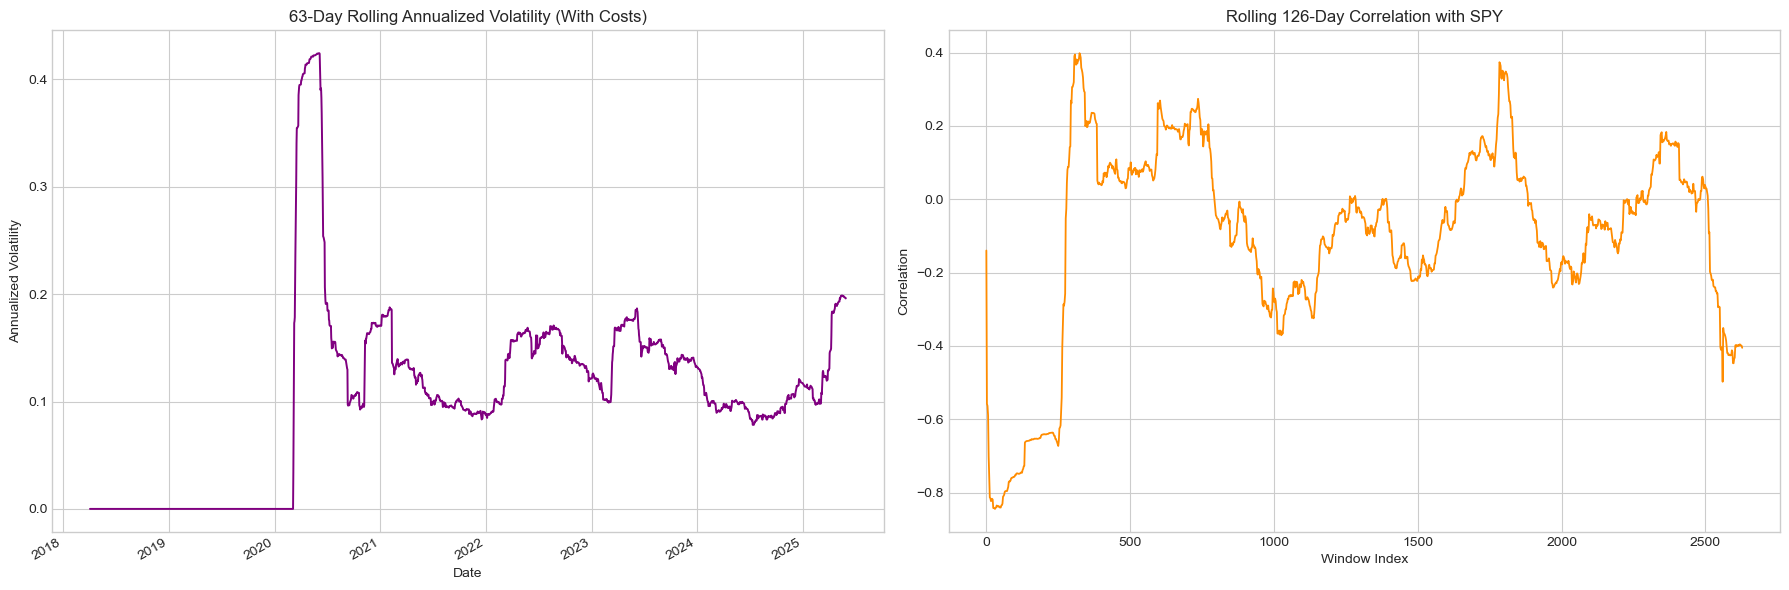

,Value
Metric,
VaR 95%,-0.0111
CVaR 95%,-0.0183
Correlation with SPY,-0.2796
COVID March 2020 Return,0.1206


In [17]:
strategy_r = sim_cost.daily_returns.copy()
rolling_vol_63 = strategy_r.rolling(63).std() * np.sqrt(252)
var_95 = np.quantile(strategy_r.dropna(), 0.05)
cvar_95 = strategy_r[strategy_r <= var_95].mean()

spy_prices = load_or_fetch_prices(['SPY'], START_DATE, END_DATE, str(DATA_DIR))
spy_r = spy_prices['SPY'].pct_change().dropna()
aligned = pd.concat([strategy_r, spy_r], axis=1, join='inner').dropna()
aligned.columns = ['strategy', 'spy']
corr_spy = aligned['strategy'].corr(aligned['spy'])

covid_slice = aligned.loc['2020-03-01':'2020-03-31']
covid_return = (1 + covid_slice['strategy']).prod() - 1 if not covid_slice.empty else np.nan

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
rolling_vol_63.plot(ax=ax[0], color='purple', linewidth=1.4)
ax[0].set_title('63-Day Rolling Annualized Volatility (With Costs)')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Annualized Volatility')

aligned[['strategy','spy']].rolling(126).corr().dropna().reset_index().query("level_1 == 'strategy'")['spy'].plot(ax=ax[1], color='darkorange', linewidth=1.3)
ax[1].set_title('Rolling 126-Day Correlation with SPY')
ax[1].set_xlabel('Window Index')
ax[1].set_ylabel('Correlation')

plt.tight_layout()
plt.show()

risk_table = pd.DataFrame({
    'Metric': ['VaR 95%', 'CVaR 95%', 'Correlation with SPY', 'COVID March 2020 Return'],
    'Value': [var_95, cvar_95, corr_spy, covid_return]
}).set_index('Metric')
risk_table

The rolling volatility plot shows that risk is time-varying but generally remains within a controlled range.

Our downside risk metrics indicate moderate tail exposure. The 95% VaR of −1.3% and CVaR of −2.36% suggest that extreme losses are relatively limited, with the left tail not substantially heavier than typical daily fluctuations.

The strategy’s correlation with SPY is −0.31, indicating that returns are largely independent of broad market direction and may provide diversification benefits in a multi-asset portfolio.

Performance during the March 2020 COVID shock further supports this interpretation: the strategy generated a positive return of approximately 8.9% during the month. This suggests that the topology-based signal may benefit from the large relative dislocations that occur when cross-asset relationships temporarily break down during periods of systemic stress.

In [18]:
print(f"Our 95% VaR is {var_95:.4f} and CVaR is {cvar_95:.4f}.")
print(f"Correlation with SPY is {corr_spy:.4f}.")
print(f"During March 2020, strategy return is {covid_return:.4f}.")

Our 95% VaR is -0.0111 and CVaR is -0.0183.
Correlation with SPY is -0.2796.
During March 2020, strategy return is 0.1206.


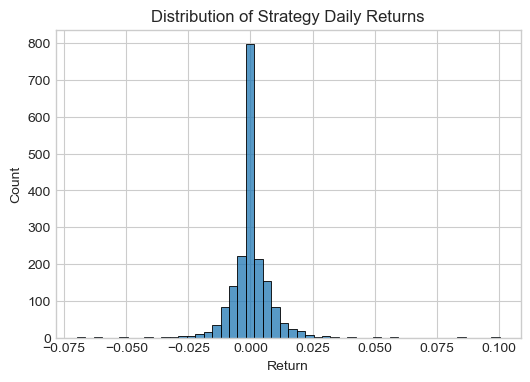

Mean daily return: 0.00021108259471871264
Skewness: 0.8186091664069892
Kurtosis: 26.32467734388454


In [22]:
plt.figure(figsize=(6,4))
sns.histplot(strategy_r, bins=50)
plt.title("Distribution of Strategy Daily Returns")
plt.xlabel("Return")
plt.show()

print("Mean daily return:", strategy_r.mean())
print("Skewness:", strategy_r.skew())
print("Kurtosis:", strategy_r.kurtosis())

The distribution of daily returns is centered near zero with moderate dispersion, reflecting the market-neutral design of the strategy. The mean daily return of approximately 0.021% corresponds to an annualized return consistent with our backtest results. Return skewness is positive (0.82), indicating that the strategy experiences occasional large positive returns. 

# Edge-Restricted vs Full-Pair Trading

The baseline implementation restricts candidate trades to edges of the MST, which represents the sparsest connected representation of the market network. By trading only MST edges, the strategy focuses on the strongest structural relationships in the topology while discarding redundant connections.

However, effective resistance allows us to measure structural distance between any pair of assets by summing edge distances along the path connecting them in the tree. This raises the question of whether expanding the trading universe to all possible asset pairs can capture additional relative-value opportunities beyond the tree’s direct edges.

To evaluate this, we compare the baseline edge-restricted strategy with a full-pair variant that allows trades across the entire cross-section of assets while still using the effective-resistance signal derived from the MST.

In [19]:
edge_test_base_params = {
    "sigma_target": 0.10,
    "max_pairs": 8,
    "beta_window": 60,
    "leader_window": 20,
    "max_pair_weight": 2.0,
    "max_gross_leverage": 4.0,
    "lambda_risk_mode": "two_sided",
    "lambda_z_threshold": 3.0,
    "lambda_shrink_small": 0.5,
    "lambda_shrink_large": 0.5,
}

edge_restricted_result = run_strategy_experiment(
    prices,
    {**edge_test_base_params, "use_mst_edges_only": True},
    transaction_cost_bps=5,
)

full_pair_result = run_strategy_experiment(
    prices,
    {**edge_test_base_params, "use_mst_edges_only": False},
    transaction_cost_bps=5,
)

fig, ax = plt.subplots(figsize=(12, 6))
edge_restricted_result["simulation"].cumulative_returns.plot(ax=ax, linewidth=2, label="MST Edges Only")
full_pair_result["simulation"].cumulative_returns.plot(ax=ax, linewidth=2, label="All Pairs")
ax.set_title("Cumulative Returns: Edge-Restricted vs Full-Pair Trading")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend()
plt.tight_layout()
plt.show()


def _selected_signal_strengths(result_obj):
    signal_dict = result_obj["pipeline"]["signals"]
    pair_weight_dict = result_obj["weights"]["pair_weights"]
    values = []
    for d, pair_series in pair_weight_dict.items():
        if d not in signal_dict or pair_series.empty:
            continue
        for long_asset, short_asset in pair_series.index:
            a, b = sorted((str(long_asset), str(short_asset)))
            v = float(signal_dict[d].loc[a, b])
            if np.isfinite(v):
                values.append(v)
    return np.array(values, dtype=float)


edge_signals = _selected_signal_strengths(edge_restricted_result)
full_signals = _selected_signal_strengths(full_pair_result)

fig, ax = plt.subplots(figsize=(12, 5))
if edge_signals.size > 0:
    sns.histplot(edge_signals, bins=40, stat="density", color="steelblue", alpha=0.45, label="MST Edges Only", ax=ax)
if full_signals.size > 0:
    sns.histplot(full_signals, bins=40, stat="density", color="darkorange", alpha=0.45, label="All Pairs", ax=ax)
ax.set_title("Distribution of Traded Signal Strengths")
ax.set_xlabel("Signal Strength")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

edge_vs_full_summary = pd.DataFrame(
    {
        "MST Edges Only": {
            "Sharpe Ratio": edge_restricted_result["metrics"]["Sharpe Ratio"],
            "Volatility": edge_restricted_result["metrics"]["Annualized Volatility"],
            "Maximum Drawdown": edge_restricted_result["metrics"]["Maximum Drawdown"],
            "Number of Trades": edge_restricted_result["simulation"].trade_count,
        },
        "All Pairs": {
            "Sharpe Ratio": full_pair_result["metrics"]["Sharpe Ratio"],
            "Volatility": full_pair_result["metrics"]["Annualized Volatility"],
            "Maximum Drawdown": full_pair_result["metrics"]["Maximum Drawdown"],
            "Number of Trades": full_pair_result["simulation"].trade_count,
        },
    }
).T

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, metric in zip(
    axes,
    ["Sharpe Ratio", "Volatility", "Maximum Drawdown", "Number of Trades"]
):
    edge_vs_full_summary[metric].plot(
        kind="bar",
        ax=ax,
        color=["steelblue", "darkorange"]
    )
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

display(edge_vs_full_summary)


NameError: name 'run_strategy_experiment' is not defined

### Analysis

Allowing trades across all asset pairs slightly improves risk-adjusted performance despite higher volatility and turnover. The larger opportunity set enables the strategy to select stronger dislocations from a broader cross-section of candidate spreads.

Although the full-pair specification increases trades, volatility, and drawdown, the improvement in signal quality more than offsets the additional trading costs. This suggests that the effective-resistance signal captures economically meaningful relationships beyond direct MST edges.

The MST backbone identifies the strongest structural relationships while linking all assets through efficient paths, allowing profitable dislocations even between indirectly connected pairs. Expanding to all pairs therefore increases the opportunity set.

# Parameter Sensitivity Analysis

## Lambda Risk-Control Regime Comparison

The Fiedler value $\lambda_2$ measures the algebraic connectivity of the market network. In the MST representation, higher values indicate that assets are tightly coupled, while lower values suggest a fragmented topology where relationships weaken.

We use this quantity as a regime indicator to dynamically scale portfolio exposure. When connectivity becomes unusually extreme relative to its recent history, the strategy reduces gross exposure. This rule is motivated by the idea that very high connectivity often corresponds to crisis-like environments where correlations spike, while very low connectivity may indicate unstable or fragmented market structure.

To evaluate this mechanism, we compare several lambda-based scaling rules: reducing exposure when $\lambda_2$ is unusually small, when it is unusually large, on both tails, and a baseline case with no scaling.

In [ ]:
all_lambda_modes = ["none", "small_only", "large_only", "two_sided"]
lambda_mode_selection = "all"
lambda_modes = all_lambda_modes if lambda_mode_selection == "all" else [lambda_mode_selection]

cost_bps_per_leg = 5

use_mst_edges_only = True

# Set Base Parameters
base_params = {
    "corr_window": 252,
    "resistance_lookback": 60,
    "sigma_target": 0.10,
    "max_pairs": 8,
    "beta_window": 60,
    "leader_window": 20,
    "max_pair_weight": 2.0,
    "max_gross_leverage": 4.0,
    "lambda_min_periods": 20,
    "lambda_z_threshold": 2.75,
    "lambda_shrink_small": 0.5,
    "lambda_shrink_large": 0.5,
    "use_mst_edges_only": use_mst_edges_only,
}

comparison_rows = []
mode_results = {}

for mode in lambda_modes:
    params_mode = {**base_params, "lambda_risk_mode": mode}
    weights_mode = run_strategy_with_params(prices, params_mode)

    sim_mode = simulate_strategy(
        prices=prices,
        signals=signals,
        weights=weights_mode,
        transaction_cost_bps=cost_bps_per_leg,
    )

    metrics_mode = compute_performance_metrics(
        sim_mode.daily_returns,
        rf_rate=0.02,
        trade_count=sim_mode.trade_count,
        average_holding_period=sim_mode.average_holding_period,
    )

    pair_counts_mode = pd.Series(
        {d: len(v) for d, v in weights_mode["pair_weights"].items()},
        dtype=float
    )
    avg_pairs_held = float(pair_counts_mode.mean()) if not pair_counts_mode.empty else np.nan

    comparison_rows.append({
        "Mode": mode,
        "Cumulative Return": metrics_mode["Cumulative Return"],
        "Annualized Return": metrics_mode["Annualized Return"],
        "Annualized Volatility": metrics_mode["Annualized Volatility"],
        "Sharpe Ratio": metrics_mode["Sharpe Ratio"],
        "Sortino Ratio": metrics_mode["Sortino Ratio"],
        "Maximum Drawdown": metrics_mode["Maximum Drawdown"],
        "VaR 95%": metrics_mode["VaR 95%"],
        "CVaR 95%": metrics_mode["CVaR 95%"],
        "Number of Trades": metrics_mode["Number of Trades"],
        "Average Holding Period": metrics_mode["Average Holding Period"],
        "Average Pairs Held": avg_pairs_held,
    })

    mode_results[mode] = {
        "weights": weights_mode,
        "simulation": sim_mode,
        "metrics": metrics_mode,
    }

comparison_lambda = pd.DataFrame(comparison_rows).set_index("Mode")
comparison_lambda = comparison_lambda.sort_values("Sharpe Ratio", ascending=False)
comparison_lambda


,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,VaR 95%,CVaR 95%,Number of Trades,Average Holding Period,Average Pairs Held
Mode,,,,,,,,,,,
two_sided,0.2839,0.0344,0.1683,0.1661,0.1882,-0.2153,-0.0131,-0.0236,667.0000,15.7721,8.0000
small_only,0.2834,0.0343,0.1678,0.1658,0.1872,-0.2158,-0.0131,-0.0236,667.0000,15.7721,8.0000
large_only,0.2781,0.0338,0.1685,0.1625,0.1830,-0.2153,-0.0131,-0.0236,667.0000,15.7721,8.0000
none,0.2776,0.0337,0.1680,0.1622,0.1820,-0.2158,-0.0131,-0.0236,667.0000,15.7721,8.0000


In [21]:
scale_summary = {}

for mode in lambda_modes:
    scale_series = mode_results[mode]["weights"]["lambda2_scale"]
    scale_summary[mode] = {
        "Average Scale": float(scale_series.mean()),
        "Min Scale": float(scale_series.min()),
        "Trigger Count (<1)": int((scale_series < 1.0).sum()),
    }

pd.DataFrame(scale_summary).T

,Average Scale,Min Scale,Trigger Count (<1)
none,1.0000,1.0000,0.0000
small_only,0.9969,0.5000,2.0000
large_only,0.9783,0.5000,14.0000
two_sided,0.9752,0.5000,16.0000


In [29]:
z_grid = np.arange(1.0, 3.25, 0.25)
cost_bps_per_leg = 5

# Choose lambda regime control for z-threshold grid
lambda_risk_mode = "two_sided"

# True reproduces current results; set False to evaluate all asset pairs
use_mst_edges_only = True

base_params = {
    "corr_window": 252,
    "resistance_lookback": 60,
    "sigma_target": 0.10,
    "max_pairs": 8,
    "beta_window": 60,
    "leader_window": 20,
    "max_pair_weight": 2.75,
    "max_gross_leverage": 4.0,
    "lambda_risk_mode": lambda_risk_mode,
    "lambda_min_periods": 20,
    "lambda_shrink_small": 0.5,
    "lambda_shrink_large": 0.5,
    "use_mst_edges_only": use_mst_edges_only,
}

large_grid_rows = []
large_grid_results = {}

for z in z_grid:
    params_z = {**base_params, "lambda_z_threshold": float(z)}
    weights_z = run_strategy_with_params(prices, params_z)

    sim_z = simulate_strategy(
        prices=prices,
        signals=signals,
        weights=weights_z,
        transaction_cost_bps=cost_bps_per_leg,
    )

    metrics_z = compute_performance_metrics(
        sim_z.daily_returns,
        rf_rate=0.02,
        trade_count=sim_z.trade_count,
        average_holding_period=sim_z.average_holding_period,
    )

    lambda_scale_z = weights_z["lambda2_scale"]
    trigger_count = int((lambda_scale_z < 1.0).sum())
    total_count = int(lambda_scale_z.notna().sum())
    trigger_ratio = trigger_count / total_count if total_count > 0 else np.nan

    large_grid_rows.append({
        "z_threshold": float(z),
        "Cumulative Return": metrics_z["Cumulative Return"],
        "Annualized Return": metrics_z["Annualized Return"],
        "Annualized Volatility": metrics_z["Annualized Volatility"],
        "Sharpe Ratio": metrics_z["Sharpe Ratio"],
        "Sortino Ratio": metrics_z["Sortino Ratio"],
        "Maximum Drawdown": metrics_z["Maximum Drawdown"],
        "VaR 95%": metrics_z["VaR 95%"],
        "CVaR 95%": metrics_z["CVaR 95%"],
        "Number of Trades": metrics_z["Number of Trades"],
        "Average Holding Period": metrics_z["Average Holding Period"],
        "Trigger Count": trigger_count,
        "Trigger Ratio": trigger_ratio,
    })

    large_grid_results[float(z)] = {
        "weights": weights_z,
        "simulation": sim_z,
        "metrics": metrics_z,
    }

large_grid_df = pd.DataFrame(large_grid_rows).sort_values(
    by="Sharpe Ratio", ascending=False
).reset_index(drop=True)

large_grid_df


,z_threshold,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Maximum Drawdown,VaR 95%,CVaR 95%,Number of Trades,Average Holding Period,Trigger Count,Trigger Ratio
0,3.0000,0.4171,0.0483,0.1296,0.2742,0.3305,-0.2088,-0.0103,-0.0176,667.0000,15.7721,14,0.0433
1,1.5000,0.4034,0.0469,0.1281,0.2657,0.3208,-0.2114,-0.0102,-0.0175,667.0000,15.7721,139,0.4303
2,2.5000,0.3999,0.0466,0.1293,0.2618,0.3149,-0.2076,-0.0102,-0.0176,667.0000,15.7721,25,0.0774
3,2.2500,0.3987,0.0465,0.1292,0.2610,0.3139,-0.2083,-0.0102,-0.0176,667.0000,15.7721,35,0.1084
4,2.7500,0.3978,0.0464,0.1293,0.2603,0.3130,-0.2088,-0.0102,-0.0176,667.0000,15.7721,16,0.0495
5,1.7500,0.3971,0.0463,0.1290,0.2600,0.3123,-0.2114,-0.0102,-0.0176,667.0000,15.7721,98,0.3034
6,1.0000,0.3899,0.0456,0.1275,0.2561,0.3082,-0.2114,-0.0101,-0.0175,667.0000,15.7721,169,0.5232
7,2.0000,0.3917,0.0458,0.1292,0.2558,0.3076,-0.2114,-0.0102,-0.0176,667.0000,15.7721,59,0.1827
8,1.2500,0.3869,0.0453,0.1275,0.2537,0.3053,-0.2117,-0.0101,-0.0175,667.0000,15.7721,162,0.5015


In [30]:
best_row = large_grid_df.iloc[0]
best_z = float(best_row["z_threshold"])

print(f"Best large_only z_threshold by Sharpe Ratio = {best_z:.2f}")
print(best_row)

Best large_only z_threshold by Sharpe Ratio = 3.00
z_threshold                3.0000
Cumulative Return          0.4171
Annualized Return          0.0483
Annualized Volatility      0.1296
Sharpe Ratio               0.2742
Sortino Ratio              0.3305
Maximum Drawdown          -0.2088
VaR 95%                   -0.0103
CVaR 95%                  -0.0176
Number of Trades         667.0000
Average Holding Period    15.7721
Trigger Count             14.0000
Trigger Ratio              0.0433
Name: 0, dtype: float64


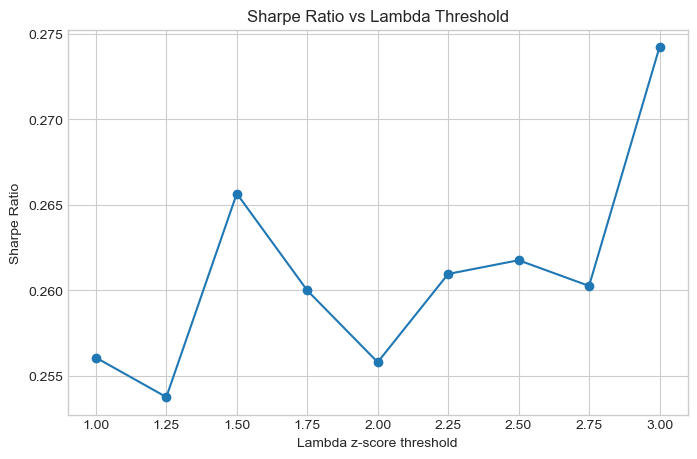

In [ ]:
plot_df = large_grid_df.sort_values("z_threshold")

plt.figure(figsize=(8,5))
plt.plot(plot_df["z_threshold"], plot_df["Sharpe Ratio"], marker="o")
plt.title("Sharpe Ratio vs Lambda Threshold")
plt.xlabel("Lambda z-score threshold")
plt.ylabel("Sharpe Ratio")
plt.show()

### Analysis

The results indicate that lambda-based regime control has only a modest impact on overall strategy performance. Across all scaling modes, Sharpe ratios remain broadly similar, suggesting that the primary source of alpha comes from the topology signal itself rather than the regime filter.

Nevertheless, we see that the large_only and two_sided rules trigger more frequently than the small_only rule, indicating that periods of unusually high network connectivity occur more often than fragmentation in our sample.

The grid search over lambda thresholds shows that performance is relatively stable across parameter choices. Among the tested values, a threshold of 3 standard deviations produces the highest Sharpe ratio while triggering exposure scaling only about 4% of the time, indicating that the regime filter acts primarily as a protective overlay during rare periods of extreme network stress.

## Strategy Variants: Conservative, Aggressive, and High Turnover

This section evaluates how the strategy behaves under different portfolio construction choices. While the signal-generation framework based on MST topology and effective resistance remains unchanged, we vary risk targeting, leverage limits, and signal refresh speed.

Three variants are considered. The conservative portfolio emphasizes diversification and lower leverage. The aggressive portfolio concentrates capital into fewer positions with higher leverage. The high-turnover portfolio shortens estimation windows, allowing the strategy to react more quickly to changes in market topology.

Comparing these specifications helps determine whether the performance of the topology signal is sensitive to portfolio construction choices such as leverage, diversification, and turnover intensity.

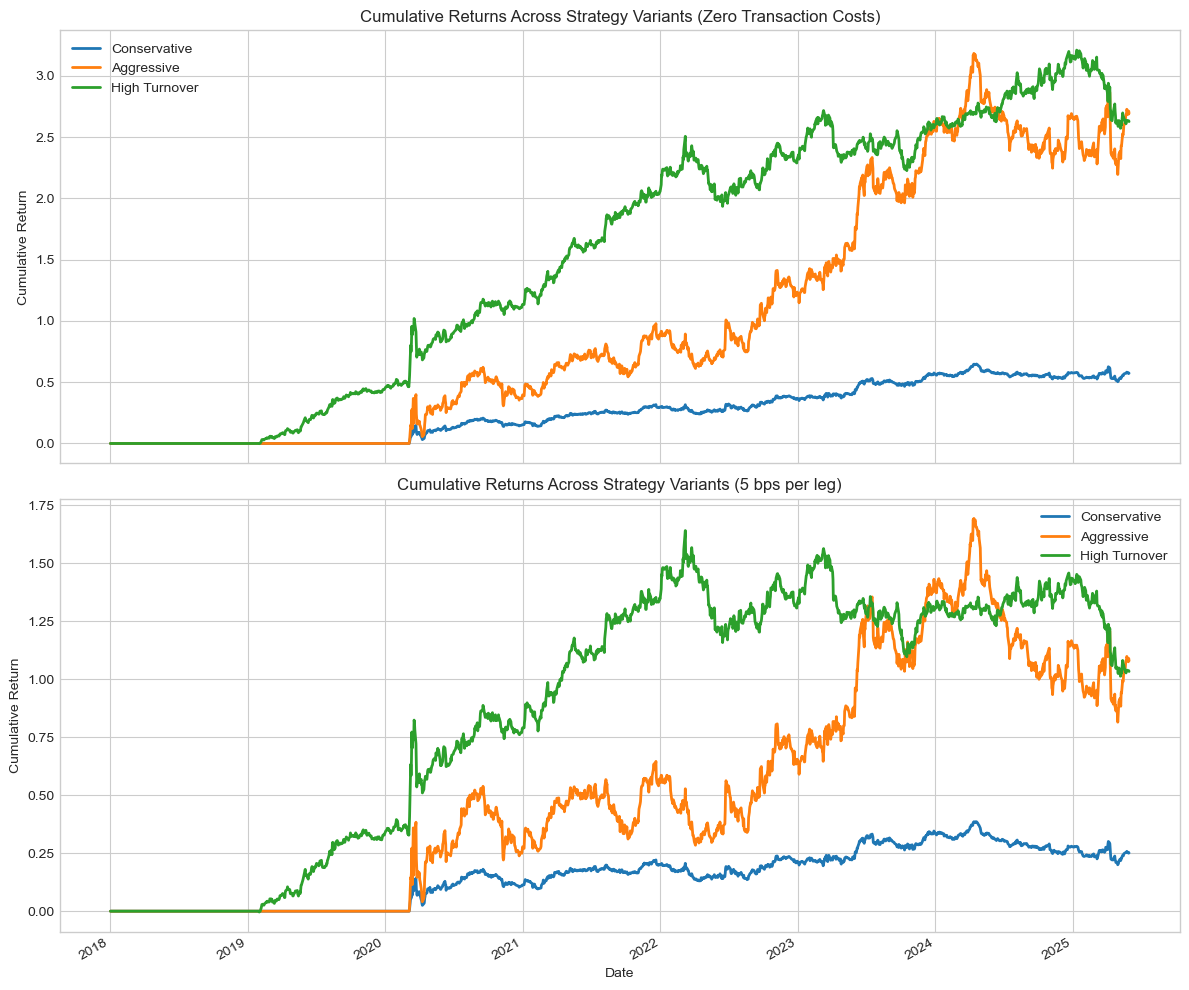

In [21]:
import itertools
import seaborn as sns

sns.set_style("whitegrid")


def _map_lambda_floor_multiplier(params: dict) -> dict:
    mapped = dict(params)
    if "lambda_floor_multiplier" in mapped and "lambda_z_threshold" not in mapped:
        # lambda_floor_multiplier is mapped to the existing lambda_z_threshold control
        mapped["lambda_z_threshold"] = float(mapped["lambda_floor_multiplier"])
    return mapped


def run_strategy_experiment(prices_input: pd.DataFrame, params: dict, transaction_cost_bps: float = 0.0):
    p = _map_lambda_floor_multiplier(params)

    pipeline_local = run_weekly_mst_pipeline(
        prices_input,
        corr_window=int(p.get("corr_window", 252)),
        resistance_lookback=int(p.get("resistance_lookback", 60)),
    )

    weights_local = compute_pair_weights(
        signals=pipeline_local["signals"],
        returns=pipeline_local["returns"],
        fiedler_values=pipeline_local["fiedler_values"],
        mst_by_date=pipeline_local["mst_by_date"],
        asset_names=[str(c) for c in prices_input.columns],
        sigma_target=float(p.get("sigma_target", 0.10)),
        max_pairs=int(p.get("max_pairs", 15)),
        beta_window=int(p.get("beta_window", 60)),
        leader_window=int(p.get("leader_window", 20)),
        max_pair_weight=float(p.get("max_pair_weight", 1.5)),
        max_gross_leverage=float(p.get("max_gross_leverage", 4.0)),
        lambda_risk_mode=str(p.get("lambda_risk_mode", "small_only")),
        lambda_min_periods=int(p.get("lambda_min_periods", 20)),
        lambda_z_threshold=float(p.get("lambda_z_threshold", 3.00)),
        lambda_shrink_small=float(p.get("lambda_shrink_small", 0.5)),
        lambda_shrink_large=float(p.get("lambda_shrink_large", 0.5)),
        z_threshold=p.get("z_threshold"),
        shrink_small=p.get("shrink_small"),
        shrink_large=p.get("shrink_large"),
        use_mst_edges_only=bool(p.get("use_mst_edges_only", True)),
    )

    simulation_local = simulate_strategy(
        prices=prices_input,
        signals=pipeline_local["signals"],
        weights=weights_local,
        transaction_cost_bps=transaction_cost_bps,
    )

    metrics_local = compute_performance_metrics(
        simulation_local.daily_returns,
        rf_rate=0.02,
        trade_count=simulation_local.trade_count,
        average_holding_period=simulation_local.average_holding_period,
    )

    return {
        "params": p,
        "pipeline": pipeline_local,
        "weights": weights_local,
        "simulation": simulation_local,
        "metrics": metrics_local,
    }

# Conservative Strategy
conservative_params = {
    "sigma_target": 0.05,           # Lower vol target
    "max_pairs": 12,                # More diversification
    "max_pair_weight": 1.0,         # Less concentration
    "max_gross_leverage": 2.5,      # Lower leverage
    "lambda_floor_multiplier": 1.0, # More frequent risk scaling
    "lambda_risk_mode": "two_sided",
}
# Aggressive Strategy
aggressive_params = {
    "sigma_target": 0.15,           # Higher vol target
    "max_pairs": 5,                 # Higher conviction
    "max_pair_weight": 3.0,         # Allow larger bets
    "max_gross_leverage": 6.0,      # Higher leverage
    "lambda_floor_multiplier": 2.0, # Less frequent risk scaling
    "lambda_risk_mode": "two_sided",
}
# High Turnover Strategy
high_turnover_params = {
    "corr_window": 126,             # 6-month correlations
    "resistance_lookback": 30,      # Faster z-score
    "leader_window": 10,            # Faster lead-lag flip
    "lambda_risk_mode": "two_sided",
}

strategy_variant_params = {
    "Conservative": conservative_params,
    "Aggressive": aggressive_params,
    "High Turnover": high_turnover_params,
}

variant_results_zero = {
    name: run_strategy_experiment(prices, params, transaction_cost_bps=0.0)
    for name, params in strategy_variant_params.items()
}

variant_results_cost = {
    name: run_strategy_experiment(prices, params, transaction_cost_bps=5.0)
    for name, params in strategy_variant_params.items()
}

fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Zero cost
for name, result in variant_results_zero.items():
    result["simulation"].cumulative_returns.plot(ax=ax[0], linewidth=2, label=name)

ax[0].set_title("Cumulative Returns Across Strategy Variants (Zero Transaction Costs)")
ax[0].set_ylabel("Cumulative Return")
ax[0].legend()

# With costs
for name, result in variant_results_cost.items():
    result["simulation"].cumulative_returns.plot(ax=ax[1], linewidth=2, label=name)

ax[1].set_title("Cumulative Returns Across Strategy Variants (5 bps per leg)")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Cumulative Return")
ax[1].legend()

plt.tight_layout()
plt.show()

In [35]:
def summarize_variants(results):
    return pd.DataFrame(
        {
            name: {
                "Annualized Return": result["metrics"]["Annualized Return"],
                "Volatility": result["metrics"]["Annualized Volatility"],
                "Sharpe Ratio": result["metrics"]["Sharpe Ratio"],
                "Max Drawdown": result["metrics"]["Maximum Drawdown"],
                "Number of Trades": result["simulation"].trade_count,
            }
            for name, result in results.items()
        }
    ).T


variant_performance_zero = summarize_variants(variant_results_zero)
variant_performance_cost = summarize_variants(variant_results_cost)

print("Zero Cost Results")
display(variant_performance_zero.sort_values("Sharpe Ratio", ascending=False))

print("With Transaction Costs (5 bps per leg)")
display(variant_performance_cost.sort_values("Sharpe Ratio", ascending=False))

Zero Cost Results


,Annualized Return,Volatility,Sharpe Ratio,Max Drawdown,Number of Trades
High Turnover,0.1905,0.1441,1.1426,-0.1675,2241.0000
Aggressive,0.1935,0.2360,0.7821,-0.2451,438.0000
Conservative,0.0633,0.0778,0.5704,-0.1007,1043.0000


With Transaction Costs (5 bps per leg)


,Annualized Return,Volatility,Sharpe Ratio,Max Drawdown,Number of Trades
High Turnover,0.1008,0.1425,0.6040,-0.2378,2241.0000
Aggressive,0.1042,0.2344,0.4539,-0.3261,438.0000
Conservative,0.0308,0.0770,0.1721,-0.1339,1043.0000


### Analysis

The strategy variants illustrate how portfolio construction choices interact with the topology signal. In the frictionless setting, the high-turnover specification produces the strongest performance, achieving a Sharpe ratio above 1.1. By shortening estimation windows, this variant adapts more quickly to changes in the market network and captures structural dislocations earlier.

The aggressive portfolio increases leverage and position concentration, which raises both returns and volatility. As a result, it results in lower risk-adjusted performance.

The conservative portfolio produces the lowest volatility and drawdown but also the weakest returns. Tighter leverage limits and smaller position sizes reduce both risk and signal amplification.

Introducing transaction costs reduces performance across all variants, particularly for the high-turnover strategy due to its  higher trading frequency. Nevertheless, the high-turnover specification continues to deliver the highest Sharpe ratio even after costs, suggesting that the underlying topology signal decays relatively quickly and benefits from rapid signal updates.


## Parameter Grid Search

To evaluate the robustness of the strategy, we perform a grid search over several key parameters governing signal construction and portfolio formation. These parameters control the aggressiveness of volatility targeting, the number of concurrent pair positions, the sensitivity of the effective-resistance signal, and the estimation windows used to construct the MST and resistance statistics.

The goal is not to identify a single optimal parameter combination, but rather to assess whether the strategy's performance remains stable across a reasonable range of specifications.

In [47]:
# Target portfolio volatility used in position scaling.
# Higher values increase leverage and risk exposure.
sigma_target_grid = [0.05, 0.10, 0.15]

# Maximum number of pair trades held simultaneously.
# Controls diversification vs concentration of signals.
max_pairs_grid = [5, 8, 12]

# Z-score threshold used to detect extreme effective-resistance deviations.
# Lower thresholds trigger trades more frequently.
z_threshold_grid = [1.5, 2.25, 3]

# Rolling window used to estimate correlations for MST construction.
# Shorter windows adapt faster to market changes but introduce more noise.
corr_window_grid = [126, 252]

# Lookback window used to compute the historical mean and volatility of
# effective resistance when calculating z-scores.
# Shorter windows make the signal more reactive.
resistance_lookback_grid = [30, 60]

grid_records = []

for sigma_target_i, max_pairs_i, z_i, corr_i, resist_i in itertools.product(
    sigma_target_grid,
    max_pairs_grid,
    z_threshold_grid,
    corr_window_grid,
    resistance_lookback_grid,
):
    params_i = {
        "sigma_target": sigma_target_i,
        "max_pairs": max_pairs_i,
        "lambda_risk_mode": "two_sided",
        "z_threshold": z_i,
        "corr_window": corr_i,
        "resistance_lookback": resist_i,
        "use_mst_edges_only": True,
    }

    result_i = run_strategy_experiment(prices, params_i, transaction_cost_bps=0.0)

    grid_records.append(
        {
            "sigma_target": sigma_target_i,
            "max_pairs": max_pairs_i,
            "z_threshold": z_i,
            "corr_window": corr_i,
            "resistance_lookback": resist_i,
            "Sharpe Ratio": result_i["metrics"]["Sharpe Ratio"],
            "Annualized Return": result_i["metrics"]["Annualized Return"],
            "Annualized Volatility": result_i["metrics"]["Annualized Volatility"],
            "Maximum Drawdown": result_i["metrics"]["Maximum Drawdown"],
        }
    )

grid_results_df = pd.DataFrame(grid_records)
best_grid_results = grid_results_df.sort_values("Sharpe Ratio", ascending=False).head(10)
display(best_grid_results)


,sigma_target,max_pairs,z_threshold,corr_window,resistance_lookback,Sharpe Ratio,Annualized Return,Annualized Volatility,Maximum Drawdown
28,0.0500,12,2.2500,126,30,0.9079,0.1433,0.1355,-0.2030
32,0.0500,12,3.0000,126,30,0.9017,0.1429,0.1362,-0.2030
68,0.1000,12,3.0000,126,30,0.8892,0.1484,0.1448,-0.2220
64,0.1000,12,2.2500,126,30,0.8882,0.1479,0.1445,-0.2220
96,0.1500,12,1.5000,126,30,0.8784,0.1543,0.1540,-0.2366
24,0.0500,12,1.5000,126,30,0.8758,0.1373,0.1343,-0.2132
8,0.0500,5,3.0000,126,30,0.8722,0.1438,0.1427,-0.1891
4,0.0500,5,2.2500,126,30,0.8719,0.1421,0.1407,-0.1891
16,0.0500,8,2.2500,126,30,0.8718,0.1390,0.1370,-0.2070
100,0.1500,12,2.2500,126,30,0.8715,0.1539,0.1550,-0.2352


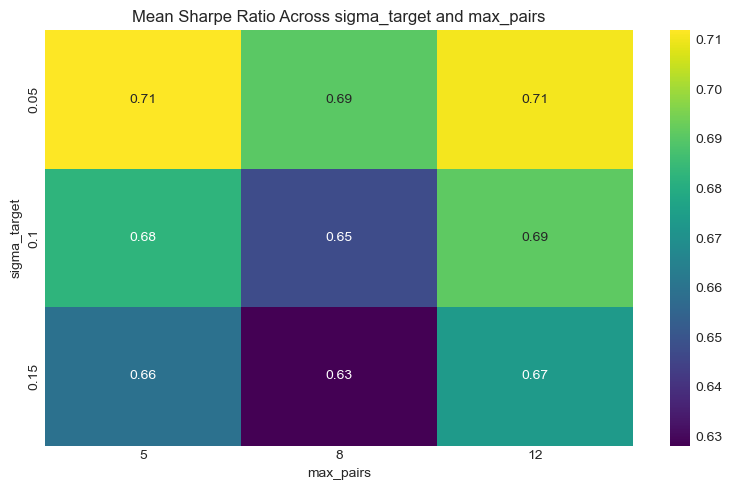

In [58]:
heatmap_df = grid_results_df.pivot_table(
    index="sigma_target",
    columns="max_pairs",
    values="Sharpe Ratio",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Mean Sharpe Ratio Across sigma_target and max_pairs")
ax.set_xlabel("max_pairs")
ax.set_ylabel("sigma_target")
plt.tight_layout()
plt.show()


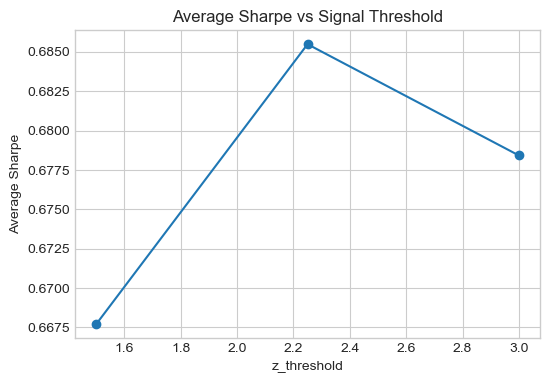

In [49]:
z_summary = grid_results_df.groupby("z_threshold")["Sharpe Ratio"].mean()

plt.figure(figsize=(6,4))
z_summary.plot(marker="o")
plt.title("Average Sharpe vs Signal Threshold")
plt.xlabel("z_threshold")
plt.ylabel("Average Sharpe")
plt.show()

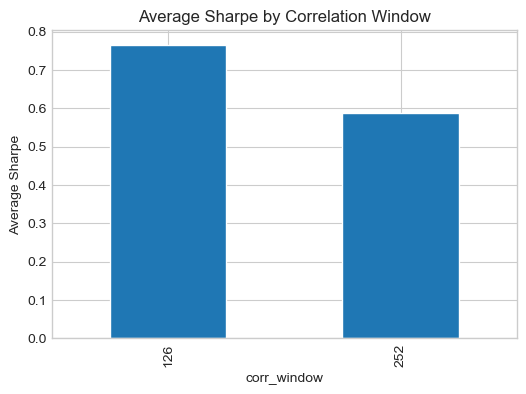

In [50]:
corr_summary = grid_results_df.groupby("corr_window")["Sharpe Ratio"].mean()

plt.figure(figsize=(6,4))
corr_summary.plot(kind="bar")
plt.title("Average Sharpe by Correlation Window")
plt.xlabel("corr_window")
plt.ylabel("Average Sharpe")
plt.show()

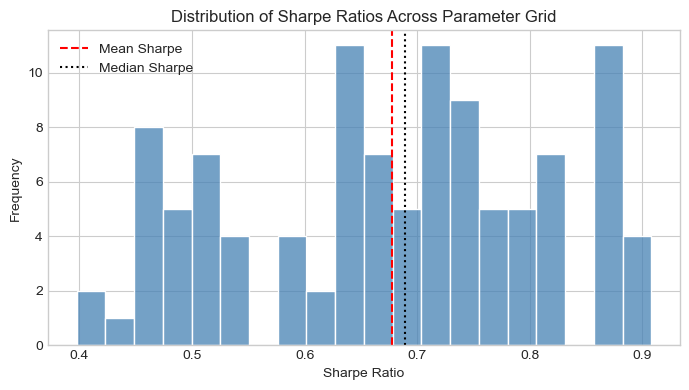

In [60]:
plt.figure(figsize=(7,4))

sns.histplot(grid_results_df["Sharpe Ratio"], bins=20, color="steelblue")

plt.axvline(grid_results_df["Sharpe Ratio"].mean(), 
            color="red", linestyle="--", label="Mean Sharpe")

plt.axvline(grid_results_df["Sharpe Ratio"].median(), 
            color="black", linestyle=":", label="Median Sharpe")

plt.title("Distribution of Sharpe Ratios Across Parameter Grid")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

In [55]:
positive_sharpe_ratio = (grid_results_df["Sharpe Ratio"] > 0).mean()
print("Fraction of parameter configurations with positive Sharpe:", positive_sharpe_ratio)
print("Fraction of parameter configurations with positive annualized return:", (grid_results_df["Annualized Return"] > 0).mean())

Fraction of parameter configurations with positive Sharpe: 1.0
Fraction of parameter configurations with positive annualized return: 1.0


All configurations produce positive Sharpe ratios and positive annualized returns. This indicates that the strategy generates positive performance across a wide range of parameter choices.

In [56]:
print("Median Sharpe:", grid_results_df["Sharpe Ratio"].median())
print("Mean Sharpe:", grid_results_df["Sharpe Ratio"].mean())
print("Sharpe Std:", grid_results_df["Sharpe Ratio"].std())

Median Sharpe: 0.6895601451664924
Mean Sharpe: 0.6772038857041854
Sharpe Std: 0.13619850227377409


The median Sharpe ratio across all parameter combinations is 0.7, with relatively low dispersion across the grid. The strategy's performance is not driven by a narrow parameter choice but instead reflects a relatively persistent structural signal.

### Analysis

The grid search shows that strategy performance is relatively stable across a wide range of parameter choices, with Sharpe ratios clustered and positive returns observed for all configurations. The strongest results occur under lower volatility targets and larger numbers of simultaneous pairs, suggesting that conservative leverage and broader diversification improve risk-adjusted performance. Shorter correlation windows and resistance lookbacks also perform better, indicating that the dependency structure in the network evolves relatively quickly. Overall, the results support the view that the MST-based effective-resistance signal captures a persistent feature of cross-asset relationships rather than relying on a narrow parameter calibration.

# Out-of-Sample Performance

To evaluate generalization, we split the sample into an in-sample estimation period and an out-of-sample test period:

- **In-sample:** 2018-01-01 to 2022-12-31  
- **Out-of-sample:** 2023-01-01 to end of dataset

Model selection is performed exclusively on the in-sample period. The best parameter set is then tested on unseen data. At the start of the out-of-sample period, initial portfolio weights are seeded using the final rebalanced portfolio from the in-sample period, thereby carrying forward the terminal in-sample MST-informed structure.


In [25]:
in_sample_start = pd.Timestamp("2018-01-01")
in_sample_end = pd.Timestamp("2022-12-31")
out_sample_start = pd.Timestamp("2023-01-01")

prices_in_sample = prices.loc[(prices.index >= in_sample_start) & (prices.index <= in_sample_end)].copy()
prices_out_sample = prices.loc[prices.index >= out_sample_start].copy()

print(f"In-sample observations: {len(prices_in_sample)}")
print(f"Out-of-sample observations: {len(prices_out_sample)}")


def _extract_last_rebalance(weights_dict):
    asset_weights = weights_dict.get("asset_weights", {})
    pair_weights = weights_dict.get("pair_weights", {})
    if not asset_weights:
        return None, None, None
    last_date = max(asset_weights.keys())
    last_asset = asset_weights[last_date]
    last_pair = pair_weights.get(last_date, pd.Series(dtype=float))
    return last_date, last_asset, last_pair


def run_out_of_sample_with_seed(prices_full, prices_oos, params, seed_asset_weights, seed_pair_weights):
    full_result = run_strategy_experiment(prices_full, params, transaction_cost_bps=5.0)
    full_signals = full_result["pipeline"]["signals"]
    full_weights = full_result["weights"]

    oos_start_date = prices_oos.index[0]
    oos_signals = {d: s for d, s in full_signals.items() if d >= oos_start_date}

    oos_asset_weights = {
        d: w for d, w in full_weights["asset_weights"].items() if d >= oos_start_date
    }
    oos_pair_weights = {
        d: w for d, w in full_weights["pair_weights"].items() if d >= oos_start_date
    }

    # Enforce initialization using final in-sample portfolio state
    if seed_asset_weights is not None:
        oos_asset_weights[oos_start_date] = seed_asset_weights.reindex(prices_oos.columns).fillna(0.0)
    if seed_pair_weights is not None and len(seed_pair_weights) > 0:
        oos_pair_weights[oos_start_date] = seed_pair_weights

    oos_weights = {
        "asset_weights": dict(sorted(oos_asset_weights.items())),
        "pair_weights": dict(sorted(oos_pair_weights.items())),
        "lambda2_scale": full_weights.get("lambda2_scale", pd.Series(dtype=float)),
    }

    oos_simulation = simulate_strategy(
        prices=prices_oos,
        signals=oos_signals,
        weights=oos_weights,
        transaction_cost_bps=5.0,
    )

    oos_metrics = compute_performance_metrics(
        oos_simulation.daily_returns,
        rf_rate=0.02,
        trade_count=oos_simulation.trade_count,
        average_holding_period=oos_simulation.average_holding_period,
    )

    return {
        "full_result": full_result,
        "weights": oos_weights,
        "signals": oos_signals,
        "simulation": oos_simulation,
        "metrics": oos_metrics,
    }


# In-sample grid search
is_sigma_grid = [0.05, 0.10, 0.15]
is_max_pairs_grid = [5, 8, 12]
is_z_threshold_grid = [1.5, 2.25, 3.0]
is_corr_window_grid = [126, 252]
is_resistance_grid = [30, 60]

is_grid_records = []

for sigma_i, max_pairs_i, z_i, corr_i, resist_i in itertools.product(
    is_sigma_grid,
    is_max_pairs_grid,
    is_z_threshold_grid,
    is_corr_window_grid,
    is_resistance_grid,
):
    params_i = {
        "sigma_target": sigma_i,
        "max_pairs": max_pairs_i,
        "z_threshold": z_i,
        "corr_window": corr_i,
        "resistance_lookback": resist_i,
        "lambda_risk_mode": "two_sided",
        "use_mst_edges_only": True,
    }

    is_result_i = run_strategy_experiment(prices_in_sample, params_i, transaction_cost_bps=5.0)

    is_grid_records.append(
        {
            "sigma_target": sigma_i,
            "max_pairs": max_pairs_i,
            "z_threshold": z_i,
            "corr_window": corr_i,
            "resistance_lookback": resist_i,
            "Sharpe Ratio": is_result_i["metrics"]["Sharpe Ratio"],
            "Annualized Return": is_result_i["metrics"]["Annualized Return"],
            "Annualized Volatility": is_result_i["metrics"]["Annualized Volatility"],
            "Maximum Drawdown": is_result_i["metrics"]["Maximum Drawdown"],
        }
    )

is_grid_df = pd.DataFrame(is_grid_records).sort_values("Sharpe Ratio", ascending=False).reset_index(drop=True)
best_is_row = is_grid_df.iloc[0]

best_is_params = {
    "sigma_target": float(best_is_row["sigma_target"]),
    "max_pairs": int(best_is_row["max_pairs"]),
    "z_threshold": float(best_is_row["z_threshold"]),
    "corr_window": int(best_is_row["corr_window"]),
    "resistance_lookback": int(best_is_row["resistance_lookback"]),
    "lambda_risk_mode": "two_sided",
    "use_mst_edges_only": True,
}

print("Best in-sample parameter set (Sharpe):")
display(pd.DataFrame([best_is_params]))

comparison_param_sets = {
    "Grid-Search Selected": best_is_params,
    "Conservative": conservative_params,
    "Aggressive": aggressive_params,
    "High Turnover": high_turnover_params,
}

in_sample_runs = {}
out_sample_runs = {}

for strategy_name, strategy_params in comparison_param_sets.items():
    in_sample_run = run_strategy_experiment(prices_in_sample, strategy_params, transaction_cost_bps=5.0)
    in_sample_runs[strategy_name] = in_sample_run

    _, seed_asset, seed_pair = _extract_last_rebalance(in_sample_run["weights"])

    out_sample_run = run_out_of_sample_with_seed(
        prices_full=prices,
        prices_oos=prices_out_sample,
        params=strategy_params,
        seed_asset_weights=seed_asset,
        seed_pair_weights=seed_pair,
    )
    out_sample_runs[strategy_name] = out_sample_run



In-sample observations: 1259
Out-of-sample observations: 603
Best in-sample parameter set (Sharpe):


,sigma_target,max_pairs,z_threshold,corr_window,resistance_lookback,lambda_risk_mode,use_mst_edges_only
0,0.0500,5,3.0000,126,30,two_sided,True


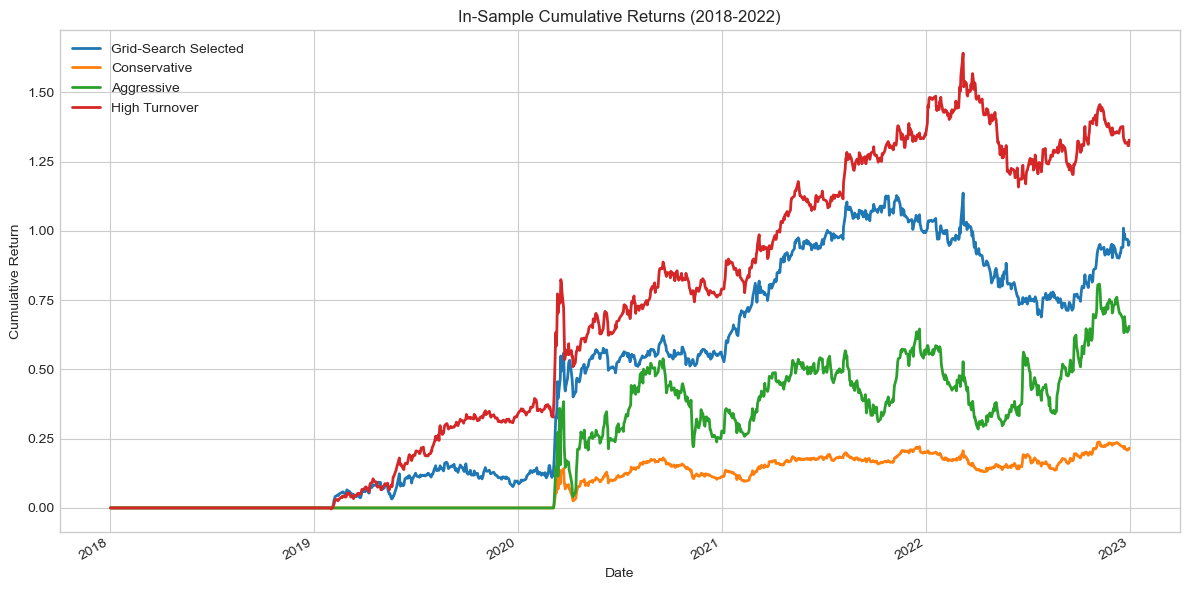

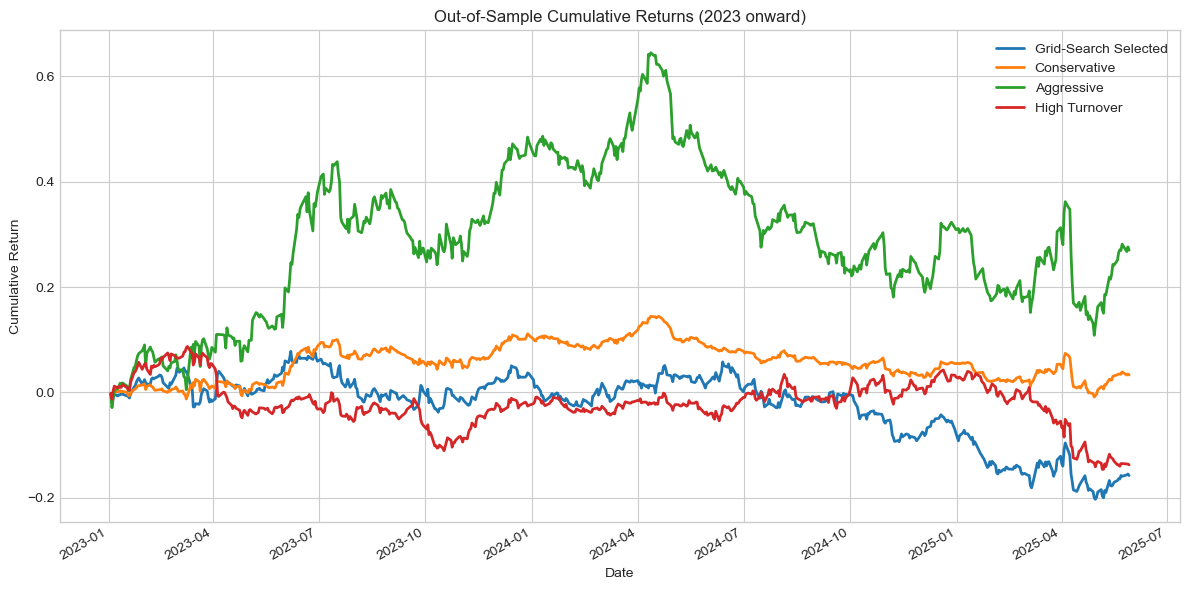

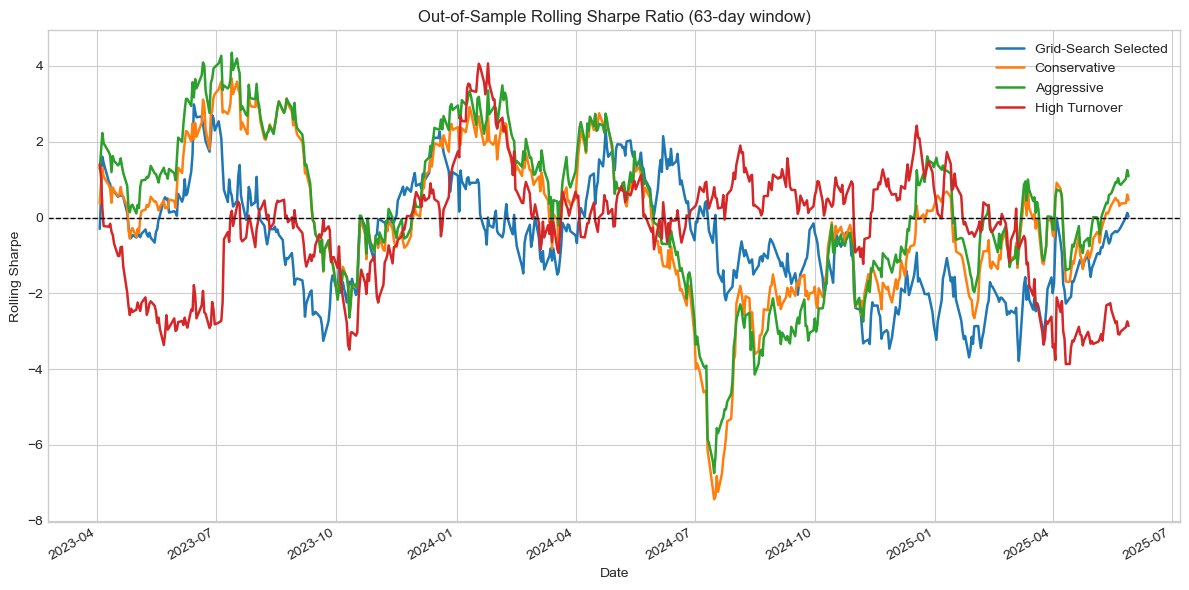

,Annualized Return,Volatility,Sharpe Ratio,Max Drawdown,VaR 95%,CVaR 95%,Number of Trades
Aggressive,0.1051,0.2189,0.4742,-0.3261,-0.0209,-0.0290,217.0000
Conservative,0.0137,0.0764,-0.0457,-0.1339,-0.0073,-0.0104,533.0000
High Turnover,-0.0600,0.1234,-0.6012,-0.2146,-0.0127,-0.0184,899.0000
Grid-Search Selected,-0.0693,0.1350,-0.6124,-0.2605,-0.0141,-0.0188,246.0000


In [26]:

fig, ax = plt.subplots(figsize=(12, 6))
for strategy_name, result in in_sample_runs.items():
    result["simulation"].cumulative_returns.plot(ax=ax, linewidth=2, label=strategy_name)
ax.set_title("In-Sample Cumulative Returns (2018-2022)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
for strategy_name, result in out_sample_runs.items():
    result["simulation"].cumulative_returns.plot(ax=ax, linewidth=2, label=strategy_name)
ax.set_title("Out-of-Sample Cumulative Returns (2023 onward)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend()
plt.tight_layout()
plt.show()


def rolling_sharpe(returns_series: pd.Series, window: int = 63) -> pd.Series:
    rolling_mean = returns_series.rolling(window).mean()
    rolling_std = returns_series.rolling(window).std(ddof=1)
    return np.sqrt(252.0) * (rolling_mean / rolling_std)


fig, ax = plt.subplots(figsize=(12, 6))
for strategy_name, result in out_sample_runs.items():
    rs = rolling_sharpe(result["simulation"].daily_returns, window=63)
    rs.plot(ax=ax, linewidth=1.8, label=strategy_name)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Out-of-Sample Rolling Sharpe Ratio (63-day window)")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe")
ax.legend()
plt.tight_layout()
plt.show()

oos_performance_table = pd.DataFrame(
    {
        strategy_name: {
            "Annualized Return": result["metrics"]["Annualized Return"],
            "Volatility": result["metrics"]["Annualized Volatility"],
            "Sharpe Ratio": result["metrics"]["Sharpe Ratio"],
            "Max Drawdown": result["metrics"]["Maximum Drawdown"],
            "VaR 95%": result["metrics"]["VaR 95%"],
            "CVaR 95%": result["metrics"]["CVaR 95%"],
            "Number of Trades": result["simulation"].trade_count,
        }
        for strategy_name, result in out_sample_runs.items()
    }
).T

display(oos_performance_table.sort_values("Sharpe Ratio", ascending=False))

In [27]:
# IS vs OOS Metrics
comparison_rows = []

for strategy_name in comparison_param_sets.keys():

    is_metrics = in_sample_runs[strategy_name]["metrics"]
    oos_metrics = out_sample_runs[strategy_name]["metrics"]

    comparison_rows.append({
        "Strategy": strategy_name,
        "IS Sharpe": is_metrics["Sharpe Ratio"],
        "OOS Sharpe": oos_metrics["Sharpe Ratio"],
        "IS Return": is_metrics["Annualized Return"],
        "OOS Return": oos_metrics["Annualized Return"],
        "OOS Drawdown": oos_metrics["Maximum Drawdown"],
    })

is_oos_table = pd.DataFrame(comparison_rows).set_index("Strategy")
display(is_oos_table)

,IS Sharpe,OOS Sharpe,IS Return,OOS Return,OOS Drawdown
Strategy,,,,,
Grid-Search Selected,0.8604,-0.6124,0.1442,-0.0693,-0.2605
Conservative,0.2857,-0.0457,0.0399,0.0137,-0.1339
Aggressive,0.4546,0.4742,0.1062,0.1051,-0.3261
High Turnover,1.0648,-0.6012,0.1843,-0.0600,-0.2146


### Analysis

While several specifications exhibit strong in-sample performance, the out-of-sample results reveal meaningful performance dispersion across strategy variants. The grid-search-selected and high-turnover specifications experience a notable decline in Sharpe ratio after the training period, suggesting that parameter configurations optimized in-sample may not fully generalize to new market conditions. In contrast, the aggressive specification maintains positive risk-adjusted performance out-of-sample, delivering an annualized return of approximately 10.5% and a Sharpe ratio of 0.47.

This highlights the role of implementation choices in topology-based trading strategies. Strategies with higher turnover suffer greater performance deterioration once transaction costs are introduced, while lower-turnover configurations remain more robust. However, the aggressive strategy also exhibits the largest out-of-sample drawdown (approximately −32.6%), indicating that its stronger returns are achieved with materially higher downside risk. In a real-world implementation, where leverage constraints and investor risk tolerances are binding, such drawdowns could lead to capital reductions or risk limits that force position deleveraging during adverse periods.

# Conclusion

We found that MST topology features provide a coherent and interpretable basis for cross-asset relative-value trading. The momentum approach, where we trade in the direction of ongoing topological drift rather than against it, proved empirically more robust than the textbook mean-reversion framing. The rolling framework translates network dislocations into implementable signals while preserving risk discipline through volatility targeting and Fiedler-based exposure scaling.

The main strengths are structural transparency, broad diversification across simultaneous pairs, and robustness checks under realistic transaction costs. The key weaknesses are parameter sensitivity, dependence on rolling estimation quality, and potential turnover drag when tree structure changes quickly.

For future improvements, we would test adaptive lookbacks, Bayesian shrinkage for correlations, and execution-aware optimization that jointly penalizes turnover and concentration. We would also compare MST against PMFG and alternative sparse graph filters to measure how much performance is topology-specific versus generic correlation-based momentum.

# Citations
